In [2]:
# ============================================================
# STEP 1: FRESH PLANTVILLAGE + MOBILENETV3 SETUP
# ============================================================

import os
import torch
import torch.nn as nn

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader


print("=" * 70)
print("STEP 1: FRESH TRAINING SETUP")
print("=" * 70)


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)


# ============================================================
# PATHS
# ============================================================

DATASET_ROOT = (
    "/kaggle/input/datasets/mohitsingh1804/"
    "plantvillage/PlantVillage"
)

TRAIN_DIR = os.path.join(
    DATASET_ROOT,
    "train"
)

VAL_DIR = os.path.join(
    DATASET_ROOT,
    "val"
)

WEIGHT_PATH = (
    "/kaggle/input/datasets/salmanalmahmud/"
    "mobilenetv3-small-weights/"
    "mobilenet_v3_small-047dcff4.pth"
)

RESULTS_DIR = (
    "/kaggle/working/plant_disease_results"
)

CHECKPOINT_DIR = os.path.join(
    RESULTS_DIR,
    "checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)


# ============================================================
# TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ============================================================
# DATASET
# ============================================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transform
)


# ============================================================
# DATALOADER
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# ============================================================
# MODEL
# ============================================================

model = models.mobilenet_v3_small(
    weights=None
)

# Load pretrained ImageNet weights
state_dict = torch.load(
    WEIGHT_PATH,
    map_location="cpu"
)

model.load_state_dict(
    state_dict
)


# Replace 1000-class classifier with 38-class classifier
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    38
)

model = model.to(device)


# ============================================================
# CHECK
# ============================================================

print("\n" + "=" * 70)
print("SETUP SUMMARY")
print("=" * 70)

print(
    "Train images:",
    len(train_dataset)
)

print(
    "Validation images:",
    len(val_dataset)
)

print(
    "Classes:",
    len(train_dataset.classes)
)

print(
    "Batch size:",
    32
)

print(
    "Model:",
    "MobileNetV3-Small"
)

print(
    "Output classes:",
    38
)

print(
    "Image size:",
    "224 x 224"
)

print(
    "Results directory:",
    RESULTS_DIR
)

print(
    "Checkpoint directory:",
    CHECKPOINT_DIR
)

print("\n✓ STEP 1 COMPLETED")

STEP 1: FRESH TRAINING SETUP

Device: cpu

SETUP SUMMARY
Train images: 43444
Validation images: 10861
Classes: 38
Batch size: 32
Model: MobileNetV3-Small
Output classes: 38
Image size: 224 x 224
Results directory: /kaggle/working/plant_disease_results
Checkpoint directory: /kaggle/working/plant_disease_results/checkpoints

✓ STEP 1 COMPLETED


In [3]:
# ============================================================
# STEP 2: FAST TRAINING + BEST MODEL SAVE
# ============================================================

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim


print("=" * 70)
print("STEP 2: FAST PLANTVILLAGE TRAINING")
print("=" * 70)


# ============================================================
# SETTINGS
# ============================================================

EPOCHS = 10
PATIENCE = 3

LEARNING_RATE = 0.0001

BEST_MODEL_PATH = os.path.join(
    RESULTS_DIR,
    "best_mobilenetv3_plantvillage.pth"
)

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "training_history.pth"
)


# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)


# ============================================================
# SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)


# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}


best_val_accuracy = 0.0
patience_counter = 0


# ============================================================
# TRAINING
# ============================================================

for epoch in range(1, EPOCHS + 1):

    start_time = time.time()

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0


    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()


        train_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)


    train_loss /= train_total

    train_accuracy = (
        100.0
        * train_correct
        / train_total
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    val_loss /= val_total

    val_accuracy = (
        100.0
        * val_correct
        / val_total
    )


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )


    # --------------------------------------------------------
    # SCHEDULER
    # --------------------------------------------------------

    scheduler.step(
        val_accuracy
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        patience_counter = 0

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "class_names":
                    train_dataset.classes,

                "val_accuracy":
                    best_val_accuracy,

                "epoch":
                    epoch
            },
            BEST_MODEL_PATH
        )

        best_status = " ★ BEST MODEL SAVED"

    else:

        patience_counter += 1

        best_status = ""


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    torch.save(
        history,
        HISTORY_PATH
    )


    # --------------------------------------------------------
    # TIME
    # --------------------------------------------------------

    elapsed = (
        time.time()
        - start_time
    )


    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    print("\n" + "-" * 70)

    print(
        f"Epoch {epoch}/{EPOCHS}"
    )

    print(
        f"Train Loss     : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy : {train_accuracy:.2f}%"
    )

    print(
        f"Val Loss       : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy   : {val_accuracy:.2f}%"
    )

    print(
        f"Best Val Acc   : {best_val_accuracy:.2f}%"
    )

    print(
        f"Time           : {elapsed / 60:.2f} min"
    )

    print(
        f"Patience       : "
        f"{patience_counter}/{PATIENCE}"
    )

    print(
        best_status
    )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print("\n" + "=" * 70)
        print("EARLY STOPPING")
        print("=" * 70)

        print(
            f"No improvement for "
            f"{PATIENCE} epochs."
        )

        break


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 TRAINING COMPLETED")
print("=" * 70)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    "\nBest model saved at:"
)

print(
    BEST_MODEL_PATH
)

print(
    "\nTraining history saved at:"
)

print(
    HISTORY_PATH
)

print("\n✓ STEP 2 COMPLETED")

STEP 2: FAST PLANTVILLAGE TRAINING

----------------------------------------------------------------------
Epoch 1/10
Train Loss     : 0.4265
Train Accuracy : 88.99%
Val Loss       : 0.0490
Val Accuracy   : 98.62%
Best Val Acc   : 98.62%
Time           : 20.55 min
Patience       : 0/3
 ★ BEST MODEL SAVED

----------------------------------------------------------------------
Epoch 2/10
Train Loss     : 0.0607
Train Accuracy : 98.11%
Val Loss       : 0.0311
Val Accuracy   : 99.06%
Best Val Acc   : 99.06%
Time           : 19.62 min
Patience       : 0/3
 ★ BEST MODEL SAVED

----------------------------------------------------------------------
Epoch 3/10
Train Loss     : 0.0349
Train Accuracy : 98.88%
Val Loss       : 0.0233
Val Accuracy   : 99.29%
Best Val Acc   : 99.29%
Time           : 20.21 min
Patience       : 0/3
 ★ BEST MODEL SAVED

----------------------------------------------------------------------
Epoch 4/10
Train Loss     : 0.0282
Train Accuracy : 99.07%
Val Loss       : 0.02

In [4]:
# ============================================================
# STEP 3: PLANTDOC CROSS-DATASET EVALUATION
# ============================================================

import os
import torch
import numpy as np

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


print("=" * 70)
print("STEP 3: PLANTDOC CROSS-DATASET EVALUATION")
print("=" * 70)


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)


# ============================================================
# 2. LOAD BEST MODEL
# ============================================================

BEST_MODEL_PATH = (
    "/kaggle/working/plant_disease_results/"
    "best_mobilenetv3_plantvillage.pth"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

model.eval()


print(
    "\nBest model loaded successfully."
)

print(
    "Training validation accuracy:",
    f"{checkpoint['val_accuracy']:.2f}%"
)

print(
    "Best epoch:",
    checkpoint["epoch"]
)


# ============================================================
# 3. PLANTDOC PATH
# ============================================================

PLANTDOC_TEST_DIR = (
    "/kaggle/input/datasets/abdulhasibuddin/"
    "plant-doc-dataset/PlantDoc-Dataset/test"
)

print("\nPlantDoc test directory:")
print(PLANTDOC_TEST_DIR)

print(
    "Directory exists:",
    os.path.exists(PLANTDOC_TEST_DIR)
)


# ============================================================
# 4. PLANTDOC TRANSFORM
# ============================================================

plantdoc_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ============================================================
# 5. PLANTDOC DATASET
# ============================================================

plantdoc_dataset = datasets.ImageFolder(
    PLANTDOC_TEST_DIR,
    transform=plantdoc_transform
)

plantdoc_loader = DataLoader(
    plantdoc_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


print("\n" + "=" * 70)
print("PLANTDOC DATASET")
print("=" * 70)

print(
    "Total images:",
    len(plantdoc_dataset)
)

print(
    "PlantDoc classes:",
    len(plantdoc_dataset.classes)
)

for i, class_name in enumerate(
    plantdoc_dataset.classes
):

    print(
        f"{i:2d} -> {class_name}"
    )


# ============================================================
# 6. PLANTDOC → PLANTVILLAGE MAPPING
# ============================================================

plantdoc_to_plantvillage = {

    "Apple Scab Leaf":
        "Apple___Apple_scab",

    "Apple rust leaf":
        "Apple___Cedar_apple_rust",

    "Bell_pepper leaf":
        "Pepper,_bell___healthy",

    "Bell_pepper leaf spot":
        "Pepper,_bell___Bacterial_spot",

    "Blueberry leaf":
        "Blueberry___healthy",

    "Cherry leaf":
        "Cherry_(including_sour)___healthy",

    "Corn Gray leaf spot":
        "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",

    "Corn leaf blight":
        "Corn_(maize)___Northern_Leaf_Blight",

    "Corn rust leaf":
        "Corn_(maize)___Common_rust_",

    "Peach leaf":
        "Peach___healthy",

    "Potato leaf early blight":
        "Potato___Early_blight",

    "Potato leaf late blight":
        "Potato___Late_blight",

    "Raspberry leaf":
        "Raspberry___healthy",

    "Soyabean leaf":
        "Soybean___healthy",

    "Squash Powdery mildew leaf":
        "Squash___Powdery_mildew",

    "Strawberry leaf":
        "Strawberry___healthy",

    "Tomato Early blight leaf":
        "Tomato___Early_blight",

    "Tomato Septoria leaf spot":
        "Tomato___Septoria_leaf_spot",

    "Tomato leaf":
        "Tomato___healthy",

    "Tomato leaf bacterial spot":
        "Tomato___Bacterial_spot",

    "Tomato leaf late blight":
        "Tomato___Late_blight",

    "Tomato leaf mosaic virus":
        "Tomato___Tomato_mosaic_virus",

    "Tomato leaf yellow virus":
        "Tomato___Tomato_Yellow_Leaf_Curl_Virus",

    "Tomato mold leaf":
        "Tomato___Leaf_Mold",

    "grape leaf":
        "Grape___healthy",

    "grape leaf black rot":
        "Grape___Black_rot"
}


# ============================================================
# 7. CREATE INDEX MAPPING
# ============================================================

plantvillage_class_to_index = {
    name: i
    for i, name in enumerate(
        train_dataset.classes
    )
}


valid_class_names = []
valid_pv_indices = []

for plantdoc_class in plantdoc_dataset.classes:

    if plantdoc_class in plantdoc_to_plantvillage:

        pv_class = (
            plantdoc_to_plantvillage[
                plantdoc_class
            ]
        )

        if pv_class in plantvillage_class_to_index:

            valid_class_names.append(
                pv_class
            )

            valid_pv_indices.append(
                plantvillage_class_to_index[
                    pv_class
                ]
            )


print("\n" + "=" * 70)
print("VALID MAPPINGS")
print("=" * 70)

print(
    "Mapped classes:",
    len(valid_class_names)
)


# ============================================================
# 8. EVALUATION
# ============================================================

y_true = []
y_pred = []

skipped = 0

# PlantDoc dataset class index → PV class index
plantdoc_index_to_pv_index = {}

for pd_index, pd_class in enumerate(
    plantdoc_dataset.classes
):

    if pd_class in plantdoc_to_plantvillage:

        pv_class = (
            plantdoc_to_plantvillage[
                pd_class
            ]
        )

        if pv_class in plantvillage_class_to_index:

            plantdoc_index_to_pv_index[
                pd_index
            ] = plantvillage_class_to_index[
                pv_class
            ]


with torch.no_grad():

    for images, labels in plantdoc_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        ).cpu().numpy()

        labels = labels.numpy()


        for true_label, prediction in zip(
            labels,
            predictions
        ):

            if true_label in plantdoc_index_to_pv_index:

                true_pv_label = (
                    plantdoc_index_to_pv_index[
                        true_label
                    ]
                )

                y_true.append(
                    true_pv_label
                )

                y_pred.append(
                    int(prediction)
                )

            else:

                skipped += 1


# ============================================================
# 9. RESULTS
# ============================================================

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(
    y_true,
    y_pred
)


print("\n" + "=" * 70)
print("PLANTDOC CROSS-DATASET RESULTS")
print("=" * 70)

print(
    "Total PlantDoc images:",
    len(plantdoc_dataset)
)

print(
    "Evaluated images:",
    len(y_true)
)

print(
    "Skipped images:",
    skipped
)

print(
    "Correct:",
    np.sum(y_true == y_pred)
)

print(
    "Incorrect:",
    np.sum(y_true != y_pred)
)

print(
    "Accuracy:",
    f"{accuracy * 100:.2f}%"
)


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    labels=valid_pv_indices,
    target_names=valid_class_names,
    zero_division=0
)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(report)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=valid_pv_indices
)


print(
    "Confusion matrix shape:",
    cm.shape
)


# ============================================================
# 12. SAVE RESULTS
# ============================================================

report_path = os.path.join(
    RESULTS_DIR,
    "plantdoc_cross_dataset_report.txt"
)

cm_path = os.path.join(
    RESULTS_DIR,
    "plantdoc_confusion_matrix.csv"
)

with open(
    report_path,
    "w"
) as f:

    f.write(
        "PlantDoc Cross-Dataset Evaluation\n"
    )

    f.write(
        f"Accuracy: {accuracy * 100:.2f}%\n\n"
    )

    f.write(
        report
    )


np.savetxt(
    cm_path,
    cm,
    delimiter=",",
    fmt="%d"
)


print("\nResults saved:")

print(
    report_path
)

print(
    cm_path
)


print("\n" + "=" * 70)
print("STEP 3 COMPLETED")
print("=" * 70)

STEP 3: PLANTDOC CROSS-DATASET EVALUATION

Device: cpu

Best model loaded successfully.
Training validation accuracy: 99.71%
Best epoch: 10

PlantDoc test directory:
/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test
Directory exists: True

PLANTDOC DATASET
Total images: 236
PlantDoc classes: 27
 0 -> Apple Scab Leaf
 1 -> Apple leaf
 2 -> Apple rust leaf
 3 -> Bell_pepper leaf
 4 -> Bell_pepper leaf spot
 5 -> Blueberry leaf
 6 -> Cherry leaf
 7 -> Corn Gray leaf spot
 8 -> Corn leaf blight
 9 -> Corn rust leaf
10 -> Peach leaf
11 -> Potato leaf early blight
12 -> Potato leaf late blight
13 -> Raspberry leaf
14 -> Soyabean leaf
15 -> Squash Powdery mildew leaf
16 -> Strawberry leaf
17 -> Tomato Early blight leaf
18 -> Tomato Septoria leaf spot
19 -> Tomato leaf
20 -> Tomato leaf bacterial spot
21 -> Tomato leaf late blight
22 -> Tomato leaf mosaic virus
23 -> Tomato leaf yellow virus
24 -> Tomato mold leaf
25 -> grape leaf
26 -> grape leaf black rot

VALID 

STEP 4: COLORED CONFUSION MATRIX

Confusion matrix shape: (26, 26)
Number of class names: 26


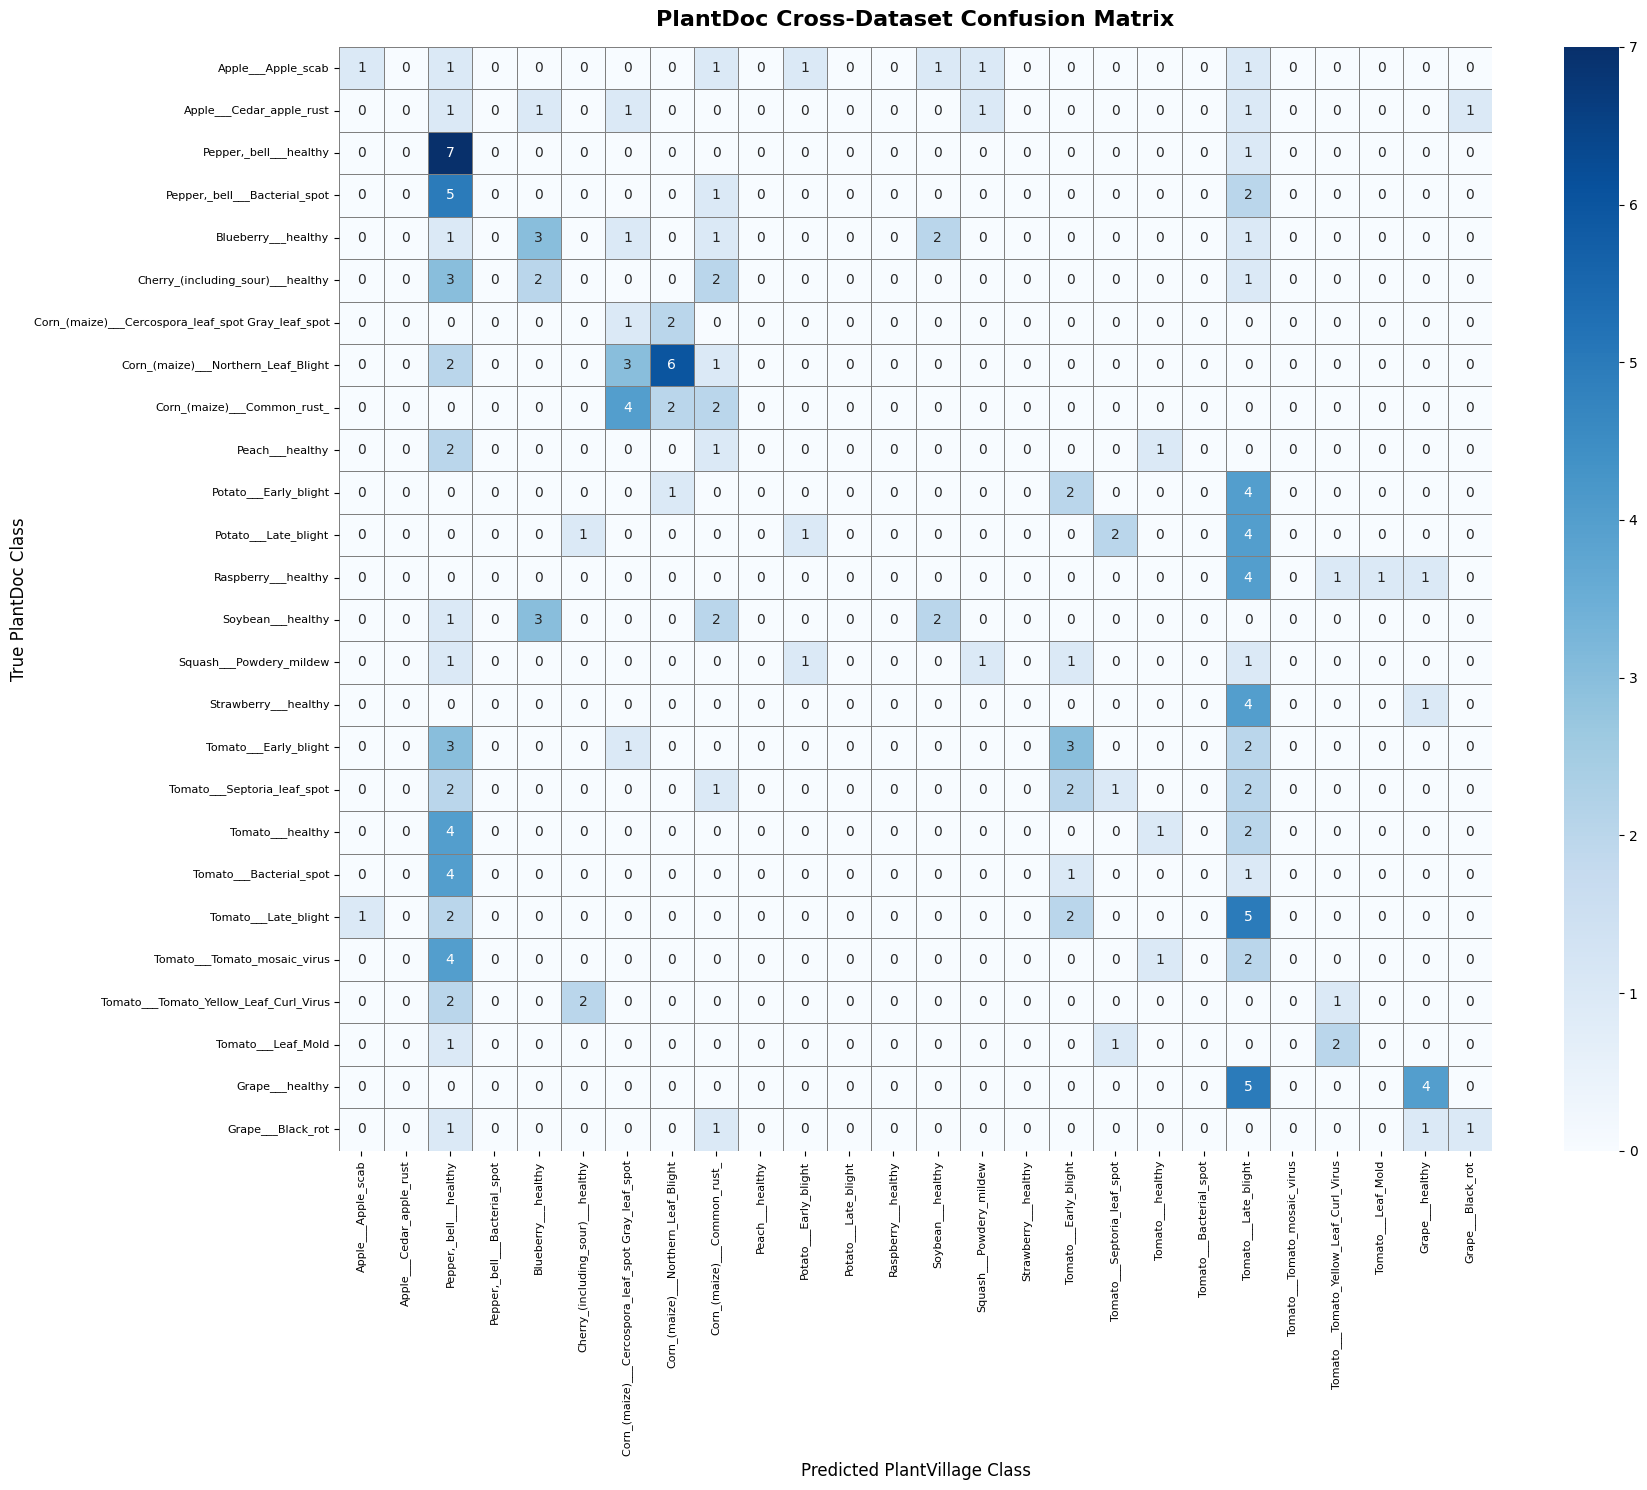


Colored confusion matrix saved:
/kaggle/working/plant_disease_results/plantdoc_colored_confusion_matrix.png

STEP 4 COMPLETED


In [5]:
# ============================================================
# STEP 4: COLORED CONFUSION MATRIX
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("STEP 4: COLORED CONFUSION MATRIX")
print("=" * 70)


# ============================================================
# CHECK VARIABLES
# ============================================================

print("\nConfusion matrix shape:", cm.shape)
print("Number of class names:", len(valid_class_names))


# ============================================================
# CREATE FIGURE
# ============================================================

plt.figure(
    figsize=(18, 15)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=valid_class_names,
    yticklabels=valid_class_names,
    linewidths=0.5,
    linecolor="gray",
    cbar=True
)


# ============================================================
# TITLE
# ============================================================

plt.title(
    "PlantDoc Cross-Dataset Confusion Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)


plt.xlabel(
    "Predicted PlantVillage Class",
    fontsize=12
)

plt.ylabel(
    "True PlantDoc Class",
    fontsize=12
)


# ============================================================
# TICK LABELS
# ============================================================

plt.xticks(
    rotation=90,
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()


cm_image_path = os.path.join(
    RESULTS_DIR,
    "plantdoc_colored_confusion_matrix.png"
)


plt.savefig(
    cm_image_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ============================================================
# FINAL
# ============================================================

print("\nColored confusion matrix saved:")
print(cm_image_path)

print("\n" + "=" * 70)
print("STEP 4 COMPLETED")
print("=" * 70)

STEP 5: TRAINING & VALIDATION CURVES

Total epochs: 10
Best validation accuracy: 99.71%
Best epoch: 10


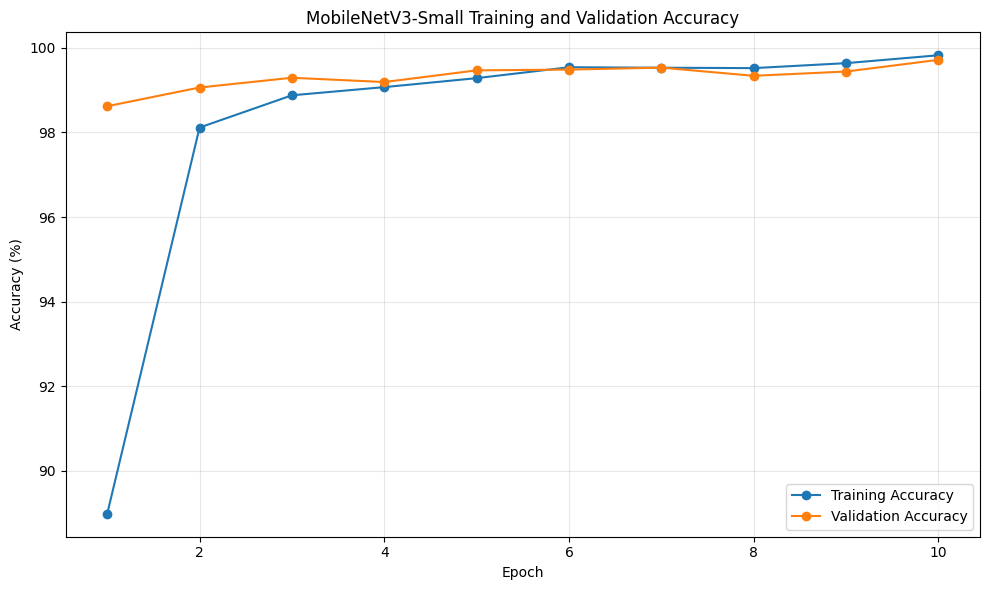

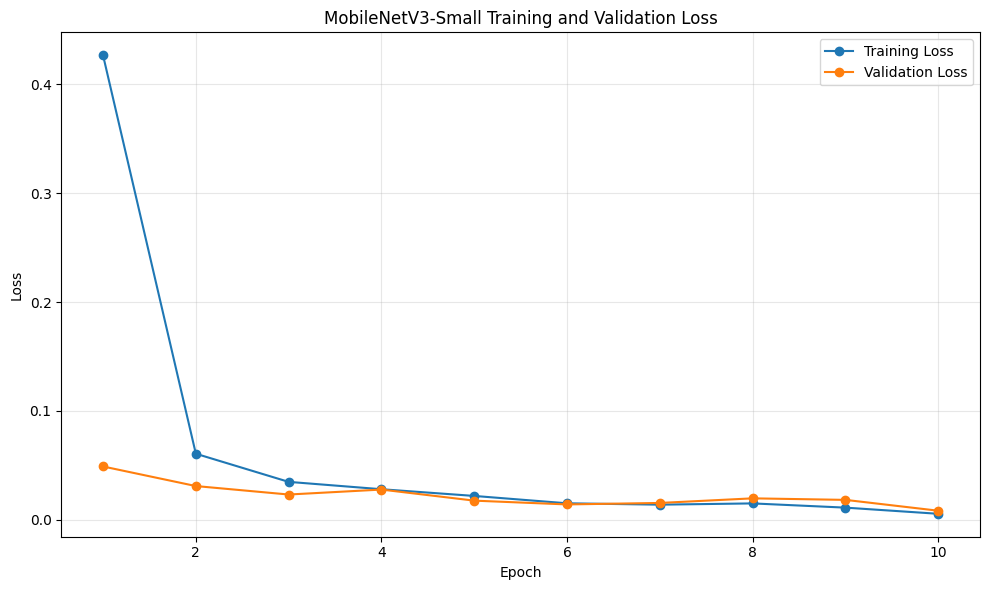


GRAPH FILES SAVED

Accuracy graph:
/kaggle/working/plant_disease_results/training_validation_accuracy.png

Loss graph:
/kaggle/working/plant_disease_results/training_validation_loss.png

STEP 5 COMPLETED


In [6]:
# ============================================================
# STEP 5: TRAINING & VALIDATION CURVES
# ============================================================

import os
import torch
import matplotlib.pyplot as plt


print("=" * 70)
print("STEP 5: TRAINING & VALIDATION CURVES")
print("=" * 70)


# ============================================================
# LOAD TRAINING HISTORY
# ============================================================

HISTORY_PATH = os.path.join(
    RESULTS_DIR,
    "training_history.pth"
)

history = torch.load(
    HISTORY_PATH,
    map_location="cpu"
)


# ============================================================
# GET VALUES
# ============================================================

train_loss = history["train_loss"]
val_loss = history["val_loss"]

train_accuracy = history["train_accuracy"]
val_accuracy = history["val_accuracy"]

epochs = range(
    1,
    len(train_loss) + 1
)


print("\nTotal epochs:", len(train_loss))

print(
    "Best validation accuracy:",
    f"{max(val_accuracy):.2f}%"
)

print(
    "Best epoch:",
    val_accuracy.index(
        max(val_accuracy)
    ) + 1
)


# ============================================================
# 1. ACCURACY CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "MobileNetV3-Small Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


accuracy_graph_path = os.path.join(
    RESULTS_DIR,
    "training_validation_accuracy.png"
)

plt.savefig(
    accuracy_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 2. LOSS CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "MobileNetV3-Small Training and Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


loss_graph_path = os.path.join(
    RESULTS_DIR,
    "training_validation_loss.png"
)

plt.savefig(
    loss_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("GRAPH FILES SAVED")
print("=" * 70)

print(
    "\nAccuracy graph:"
)

print(
    accuracy_graph_path
)

print(
    "\nLoss graph:"
)

print(
    loss_graph_path
)

print("\n" + "=" * 70)
print("STEP 5 COMPLETED")
print("=" * 70)

In [7]:
# ============================================================
# STEP 6: FINAL RESULT SUMMARY
# ============================================================

import os
import pandas as pd
import numpy as np


print("=" * 70)
print("STEP 6: FINAL RESULT SUMMARY")
print("=" * 70)


# ============================================================
# TRAINING RESULTS
# ============================================================

best_val_accuracy = max(val_accuracy)

best_epoch = (
    val_accuracy.index(best_val_accuracy) + 1
)

final_train_accuracy = train_accuracy[-1]
final_val_accuracy = val_accuracy[-1]


# ============================================================
# PLANTDOC RESULTS
# ============================================================

plantdoc_accuracy = accuracy * 100

correct_predictions = int(
    np.sum(y_true == y_pred)
)

incorrect_predictions = int(
    np.sum(y_true != y_pred)
)

evaluated_images = len(y_true)


# ============================================================
# CLASSIFICATION METRICS
# ============================================================

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=valid_pv_indices,
        average="weighted",
        zero_division=0
    )
)


macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=valid_pv_indices,
        average="macro",
        zero_division=0
    )
)


# ============================================================
# RESULT TABLE
# ============================================================

results = pd.DataFrame({

    "Metric": [
        "Model",
        "Training Dataset",
        "Training Images",
        "Validation Images",
        "Number of Classes",
        "Training Epochs",
        "Best Epoch",
        "Best Validation Accuracy",
        "Final Training Accuracy",
        "Final Validation Accuracy",
        "PlantDoc Test Images",
        "PlantDoc Evaluated Images",
        "PlantDoc Skipped Images",
        "PlantDoc Correct Predictions",
        "PlantDoc Incorrect Predictions",
        "PlantDoc Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-score",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score"
    ],

    "Value": [
        "MobileNetV3-Small",
        "PlantVillage",
        len(train_dataset),
        len(val_dataset),
        len(train_dataset.classes),
        len(train_loss),
        best_epoch,
        f"{best_val_accuracy:.2f}%",
        f"{final_train_accuracy:.2f}%",
        f"{final_val_accuracy:.2f}%",
        len(plantdoc_dataset),
        evaluated_images,
        skipped,
        correct_predictions,
        incorrect_predictions,
        f"{plantdoc_accuracy:.2f}%",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{macro_precision:.4f}",
        f"{macro_recall:.4f}",
        f"{macro_f1:.4f}"
    ]
})


# ============================================================
# DISPLAY
# ============================================================

print("\n")

print(
    results.to_string(
        index=False
    )
)


# ============================================================
# SAVE CSV
# ============================================================

final_results_path = os.path.join(
    RESULTS_DIR,
    "final_results_summary.csv"
)

results.to_csv(
    final_results_path,
    index=False
)


# ============================================================
# SAVE TEXT REPORT
# ============================================================

final_report_path = os.path.join(
    RESULTS_DIR,
    "final_experiment_summary.txt"
)

with open(
    final_report_path,
    "w"
) as f:

    f.write(
        "====================================================\n"
    )

    f.write(
        "FINAL EXPERIMENT SUMMARY\n"
    )

    f.write(
        "====================================================\n\n"
    )

    f.write(
        results.to_string(
            index=False
        )
    )

    f.write("\n\n")

    f.write(
        "Cross-Dataset Interpretation\n"
    )

    f.write(
        "----------------------------------------\n"
    )

    f.write(
        f"PlantVillage best validation accuracy: "
        f"{best_val_accuracy:.2f}%\n"
    )

    f.write(
        f"PlantDoc cross-dataset accuracy: "
        f"{plantdoc_accuracy:.2f}%\n"
    )

    f.write(
        f"Accuracy drop: "
        f"{best_val_accuracy - plantdoc_accuracy:.2f} percentage points\n"
    )


# ============================================================
# PRINT IMPORTANT RESULTS
# ============================================================

print("\n" + "=" * 70)
print("IMPORTANT THESIS RESULTS")
print("=" * 70)

print(
    f"\nPlantVillage Validation Accuracy : "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"PlantDoc Cross-Dataset Accuracy  : "
    f"{plantdoc_accuracy:.2f}%"
)

print(
    f"Accuracy Drop                    : "
    f"{best_val_accuracy - plantdoc_accuracy:.2f} percentage points"
)

print(
    f"\nPlantDoc Weighted Precision      : "
    f"{precision:.4f}"
)

print(
    f"PlantDoc Weighted Recall         : "
    f"{recall:.4f}"
)

print(
    f"PlantDoc Weighted F1              : "
    f"{f1:.4f}"
)

print(
    f"\nPlantDoc Macro F1                 : "
    f"{macro_f1:.4f}"
)


print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(
    final_results_path
)

print(
    final_report_path
)

print("\n" + "=" * 70)
print("STEP 6 COMPLETED")
print("=" * 70)

STEP 6: FINAL RESULT SUMMARY


                        Metric             Value
                         Model MobileNetV3-Small
              Training Dataset      PlantVillage
               Training Images             43444
             Validation Images             10861
             Number of Classes                38
               Training Epochs                10
                    Best Epoch                10
      Best Validation Accuracy            99.71%
       Final Training Accuracy            99.82%
     Final Validation Accuracy            99.71%
          PlantDoc Test Images               236
     PlantDoc Evaluated Images               227
       PlantDoc Skipped Images                 9
  PlantDoc Correct Predictions                39
PlantDoc Incorrect Predictions               188
             PlantDoc Accuracy            17.18%
            Weighted Precision            0.1978
               Weighted Recall            0.1718
             Weighted F1-score        

STEP 7: GRAD-CAM EXPLAINABILITY


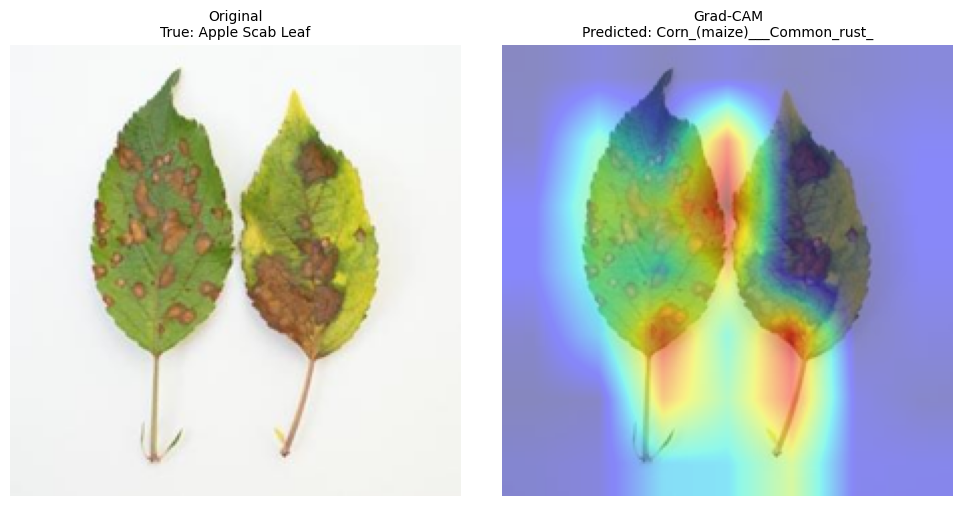


Sample 1
Image: /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test/Apple Scab Leaf/Apple Scab Leaf (1).jpg
True: Apple Scab Leaf
Predicted: Corn_(maize)___Common_rust_
Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_sample_1.png


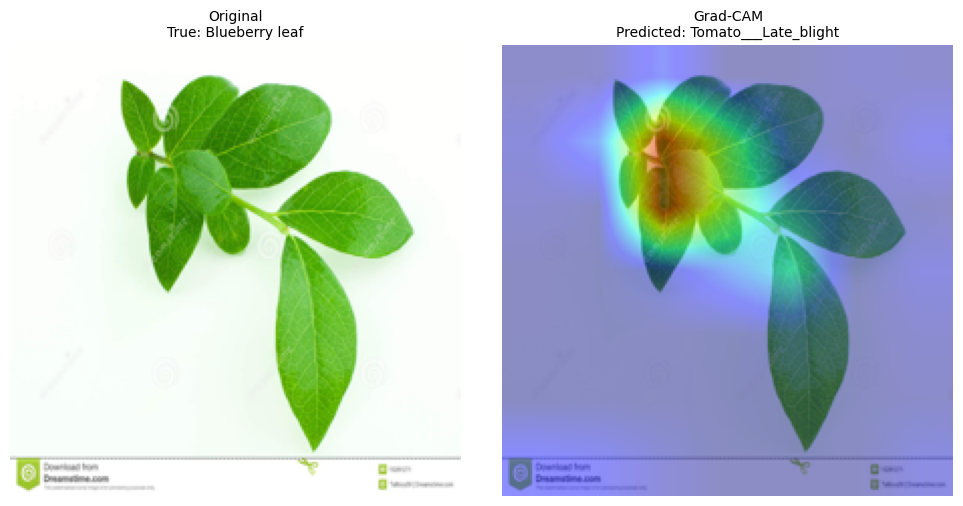


Sample 2
Image: /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test/Blueberry leaf/Blueberry leaf (3).jpg
True: Blueberry leaf
Predicted: Tomato___Late_blight
Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_sample_2.png


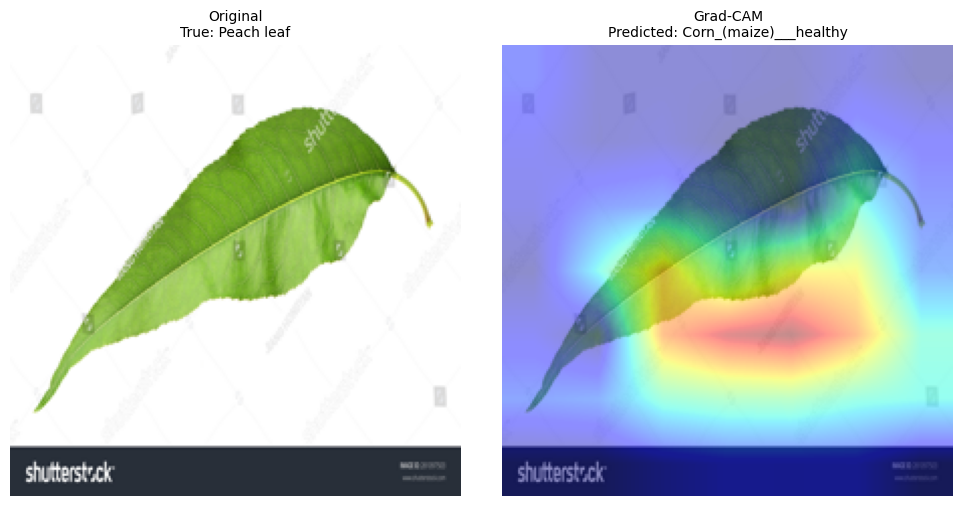


Sample 3
Image: /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test/Peach leaf/Peach leaf (8).jpg
True: Peach leaf
Predicted: Corn_(maize)___healthy
Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_sample_3.png


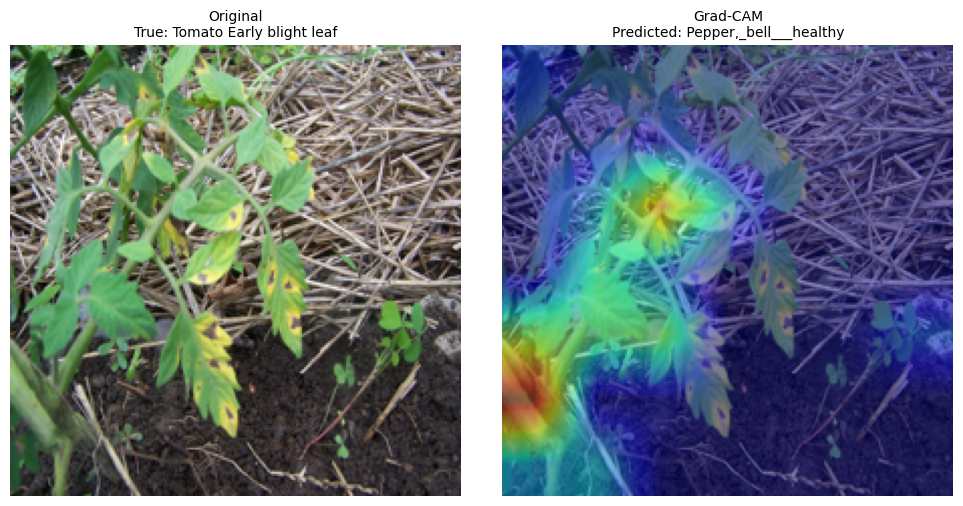


Sample 4
Image: /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test/Tomato Early blight leaf/Tomato Early blight leaf (4).jpg
True: Tomato Early blight leaf
Predicted: Pepper,_bell___healthy
Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_sample_4.png

GRAD-CAM COMPLETED

Grad-CAM directory:
/kaggle/working/plant_disease_results/gradcam

✓ STEP 7 COMPLETED


In [8]:
# ============================================================
# STEP 7: GRAD-CAM EXPLAINABILITY
# ============================================================

import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image


print("=" * 70)
print("STEP 7: GRAD-CAM EXPLAINABILITY")
print("=" * 70)


# ============================================================
# GRAD-CAM CLASS
# ============================================================

class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(
            self.save_activation
        )

        target_layer.register_full_backward_hook(
            self.save_gradient
        )


    def save_activation(
        self,
        module,
        input,
        output
    ):

        self.activations = output


    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0]


    def generate(
        self,
        image,
        class_index=None
    ):

        self.model.zero_grad()

        output = self.model(image)

        if class_index is None:

            class_index = output.argmax(
                dim=1
            ).item()


        score = output[
            0,
            class_index
        ]

        score.backward()


        activations = self.activations
        gradients = self.gradients


        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )


        cam = (
            weights * activations
        ).sum(
            dim=1,
            keepdim=True
        )


        cam = F.relu(cam)


        cam = F.interpolate(
            cam,
            size=(
                image.shape[2],
                image.shape[3]
            ),
            mode="bilinear",
            align_corners=False
        )


        cam = cam.squeeze().detach().cpu().numpy()


        cam -= cam.min()

        if cam.max() > 0:

            cam /= cam.max()


        return cam, class_index


# ============================================================
# TARGET LAYER
# ============================================================

target_layer = model.features[-1]


gradcam = GradCAM(
    model,
    target_layer
)


# ============================================================
# SELECT 4 PLANTDOC IMAGES
# ============================================================

selected_indices = [
    0,
    50,
    100,
    150
]


# ============================================================
# RESULTS DIRECTORY
# ============================================================

XAI_DIR = os.path.join(
    RESULTS_DIR,
    "gradcam"
)

os.makedirs(
    XAI_DIR,
    exist_ok=True
)


# ============================================================
# NORMALIZATION VALUES
# ============================================================

mean = np.array(
    [0.485, 0.456, 0.406]
)

std = np.array(
    [0.229, 0.224, 0.225]
)


# ============================================================
# PROCESS IMAGES
# ============================================================

for counter, dataset_index in enumerate(
    selected_indices,
    start=1
):

    image_path, true_label = (
        plantdoc_dataset.samples[
            dataset_index
        ]
    )


    # --------------------------------------------------------
    # LOAD IMAGE
    # --------------------------------------------------------

    original_image = Image.open(
        image_path
    ).convert("RGB")


    display_image = original_image.resize(
        (224, 224)
    )


    # --------------------------------------------------------
    # TRANSFORM
    # --------------------------------------------------------

    image_tensor = (
        plantdoc_dataset[
            dataset_index
        ][0]
        .unsqueeze(0)
        .to(device)
    )


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        output = model(
            image_tensor
        )

        prediction = output.argmax(
            dim=1
        ).item()


    # --------------------------------------------------------
    # GRAD-CAM
    # --------------------------------------------------------

    cam, predicted_class = (
        gradcam.generate(
            image_tensor,
            prediction
        )
    )


    # --------------------------------------------------------
    # TRUE CLASS
    # --------------------------------------------------------

    true_class = (
        plantdoc_dataset.classes[
            true_label
        ]
    )

    predicted_class_name = (
        train_dataset.classes[
            predicted_class
        ]
    )


    # --------------------------------------------------------
    # CREATE FIGURE
    # --------------------------------------------------------

    plt.figure(
        figsize=(10, 5)
    )


    # Original image
    plt.subplot(
        1,
        2,
        1
    )

    plt.imshow(
        display_image
    )

    plt.title(
        f"Original\nTrue: {true_class}",
        fontsize=10
    )

    plt.axis(
        "off"
    )


    # Grad-CAM
    plt.subplot(
        1,
        2,
        2
    )

    plt.imshow(
        display_image
    )

    plt.imshow(
        cam,
        cmap="jet",
        alpha=0.45
    )

    plt.title(
        f"Grad-CAM\nPredicted: {predicted_class_name}",
        fontsize=10
    )

    plt.axis(
        "off"
    )


    plt.tight_layout()


    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    output_path = os.path.join(
        XAI_DIR,
        f"gradcam_sample_{counter}.png"
    )


    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    print(
        f"\nSample {counter}"
    )

    print(
        "Image:",
        image_path
    )

    print(
        "True:",
        true_class
    )

    print(
        "Predicted:",
        predicted_class_name
    )

    print(
        "Saved:",
        output_path
    )


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("GRAD-CAM COMPLETED")
print("=" * 70)

print(
    "\nGrad-CAM directory:"
)

print(
    XAI_DIR
)

print("\n✓ STEP 7 COMPLETED")

In [9]:
# ============================================================
# STEP 8: FINAL THESIS RESULT PACKAGE
# ============================================================

import os
import shutil
import pandas as pd


print("=" * 70)
print("STEP 8: FINAL THESIS RESULT PACKAGE")
print("=" * 70)


# ============================================================
# FINAL DIRECTORY
# ============================================================

FINAL_DIR = os.path.join(
    "/kaggle/working",
    "FINAL_THESIS_RESULTS"
)

os.makedirs(
    FINAL_DIR,
    exist_ok=True
)


# ============================================================
# COPY IMPORTANT FILES
# ============================================================

files_to_copy = [

    (
        BEST_MODEL_PATH,
        "best_mobilenetv3_plantvillage.pth"
    ),

    (
        os.path.join(
            RESULTS_DIR,
            "training_history.pth"
        ),
        "training_history.pth"
    ),

    (
        os.path.join(
            RESULTS_DIR,
            "final_results_summary.csv"
        ),
        "final_results_summary.csv"
    ),

    (
        os.path.join(
            RESULTS_DIR,
            "final_experiment_summary.txt"
        ),
        "final_experiment_summary.txt"
    ),

    (
        os.path.join(
            RESULTS_DIR,
            "plantdoc_cross_dataset_report.txt"
        ),
        "plantdoc_cross_dataset_report.txt"
    ),

    (
        os.path.join(
            RESULTS_DIR,
            "plantdoc_confusion_matrix.csv"
        ),
        "plantdoc_confusion_matrix.csv"
    ),

    (
        os.path.join(
            RESULTS_DIR,
            "plantdoc_colored_confusion_matrix.png"
        ),
        "plantdoc_colored_confusion_matrix.png"
    ),

    (
        os.path.join(
            RESULTS_DIR,
            "training_validation_accuracy.png"
        ),
        "training_validation_accuracy.png"
    ),

    (
        os.path.join(
            RESULTS_DIR,
            "training_validation_loss.png"
        ),
        "training_validation_loss.png"
    )
]


print("\nCopying important files...\n")


for source, filename in files_to_copy:

    destination = os.path.join(
        FINAL_DIR,
        filename
    )

    if os.path.exists(source):

        shutil.copy2(
            source,
            destination
        )

        print(
            "✓",
            filename
        )

    else:

        print(
            "⚠ NOT FOUND:",
            source
        )


# ============================================================
# COPY GRAD-CAM DIRECTORY
# ============================================================

XAI_SOURCE = os.path.join(
    RESULTS_DIR,
    "gradcam"
)

XAI_DEST = os.path.join(
    FINAL_DIR,
    "gradcam"
)


if os.path.exists(XAI_SOURCE):

    shutil.copytree(
        XAI_SOURCE,
        XAI_DEST,
        dirs_exist_ok=True
    )

    print(
        "\n✓ Grad-CAM images copied"
    )

else:

    print(
        "\n⚠ Grad-CAM directory not found"
    )


# ============================================================
# CREATE FINAL THESIS SUMMARY
# ============================================================

summary_path = os.path.join(
    FINAL_DIR,
    "THESIS_FINAL_RESULTS.txt"
)


with open(
    summary_path,
    "w"
) as f:

    f.write(
        "=" * 70 + "\n"
    )

    f.write(
        "FINAL THESIS EXPERIMENT RESULTS\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )


    f.write(
        "MODEL\n"
    )

    f.write(
        "----------------------------------------\n"
    )

    f.write(
        "Architecture: MobileNetV3-Small\n"
    )

    f.write(
        "Input Size: 224 x 224\n"
    )

    f.write(
        "Training Dataset: PlantVillage\n"
    )

    f.write(
        "External Test Dataset: PlantDoc\n\n"
    )


    f.write(
        "TRAINING\n"
    )

    f.write(
        "----------------------------------------\n"
    )

    f.write(
        f"Training Images: {len(train_dataset)}\n"
    )

    f.write(
        f"Validation Images: {len(val_dataset)}\n"
    )

    f.write(
        f"Classes: {len(train_dataset.classes)}\n"
    )

    f.write(
        f"Epochs: {len(train_loss)}\n"
    )

    f.write(
        f"Best Epoch: {best_epoch}\n"
    )

    f.write(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.2f}%\n"
    )

    f.write(
        f"Final Training Accuracy: "
        f"{final_train_accuracy:.2f}%\n"
    )

    f.write(
        f"Final Validation Accuracy: "
        f"{final_val_accuracy:.2f}%\n\n"
    )


    f.write(
        "CROSS-DATASET EVALUATION\n"
    )

    f.write(
        "----------------------------------------\n"
    )

    f.write(
        f"PlantDoc Images: "
        f"{len(plantdoc_dataset)}\n"
    )

    f.write(
        f"Evaluated Images: "
        f"{evaluated_images}\n"
    )

    f.write(
        f"Skipped Images: "
        f"{skipped}\n"
    )

    f.write(
        f"Correct Predictions: "
        f"{correct_predictions}\n"
    )

    f.write(
        f"Incorrect Predictions: "
        f"{incorrect_predictions}\n"
    )

    f.write(
        f"Accuracy: "
        f"{plantdoc_accuracy:.2f}%\n"
    )

    f.write(
        f"Weighted Precision: "
        f"{precision:.4f}\n"
    )

    f.write(
        f"Weighted Recall: "
        f"{recall:.4f}\n"
    )

    f.write(
        f"Weighted F1-score: "
        f"{f1:.4f}\n"
    )

    f.write(
        f"Macro Precision: "
        f"{macro_precision:.4f}\n"
    )

    f.write(
        f"Macro Recall: "
        f"{macro_recall:.4f}\n"
    )

    f.write(
        f"Macro F1-score: "
        f"{macro_f1:.4f}\n\n"
    )


    f.write(
        "GENERALIZATION GAP\n"
    )

    f.write(
        "----------------------------------------\n"
    )

    f.write(
        f"PlantVillage Validation Accuracy: "
        f"{best_val_accuracy:.2f}%\n"
    )

    f.write(
        f"PlantDoc Accuracy: "
        f"{plantdoc_accuracy:.2f}%\n"
    )

    f.write(
        f"Accuracy Drop: "
        f"{best_val_accuracy - plantdoc_accuracy:.2f} "
        f"percentage points\n\n"
    )


    f.write(
        "EXPLAINABILITY\n"
    )

    f.write(
        "----------------------------------------\n"
    )

    f.write(
        "Grad-CAM visualizations generated "
        "for representative PlantDoc images.\n"
    )


# ============================================================
# LIST FINAL FILES
# ============================================================

print("\n" + "=" * 70)
print("FINAL RESULT FILES")
print("=" * 70)

for root, dirs, files in os.walk(
    FINAL_DIR
):

    for file in files:

        full_path = os.path.join(
            root,
            file
        )

        relative_path = os.path.relpath(
            full_path,
            FINAL_DIR
        )

        print(
            "✓",
            relative_path
        )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL THESIS RESULTS")
print("=" * 70)

print(
    "\nModel: MobileNetV3-Small"
)

print(
    f"PlantVillage Validation: "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"PlantDoc Accuracy: "
    f"{plantdoc_accuracy:.2f}%"
)

print(
    f"Weighted F1: "
    f"{f1:.4f}"
)

print(
    f"Macro F1: "
    f"{macro_f1:.4f}"
)

print(
    f"Generalization Gap: "
    f"{best_val_accuracy - plantdoc_accuracy:.2f} percentage points"
)

print(
    "\nFinal package:"
)

print(
    FINAL_DIR
)

print("\n" + "=" * 70)
print("STEP 8 COMPLETED")
print("=" * 70)

print("\n🎉 EXPERIMENT PIPELINE COMPLETED")

STEP 8: FINAL THESIS RESULT PACKAGE

Copying important files...

✓ best_mobilenetv3_plantvillage.pth
✓ training_history.pth
✓ final_results_summary.csv
✓ final_experiment_summary.txt
✓ plantdoc_cross_dataset_report.txt
✓ plantdoc_confusion_matrix.csv
✓ plantdoc_colored_confusion_matrix.png
✓ training_validation_accuracy.png
✓ training_validation_loss.png

✓ Grad-CAM images copied

FINAL RESULT FILES
✓ final_experiment_summary.txt
✓ training_history.pth
✓ final_results_summary.csv
✓ training_validation_accuracy.png
✓ plantdoc_cross_dataset_report.txt
✓ plantdoc_colored_confusion_matrix.png
✓ plantdoc_confusion_matrix.csv
✓ training_validation_loss.png
✓ THESIS_FINAL_RESULTS.txt
✓ best_mobilenetv3_plantvillage.pth
✓ gradcam/gradcam_sample_2.png
✓ gradcam/gradcam_sample_3.png
✓ gradcam/gradcam_sample_1.png
✓ gradcam/gradcam_sample_4.png

FINAL THESIS RESULTS

Model: MobileNetV3-Small
PlantVillage Validation: 99.71%
PlantDoc Accuracy: 17.18%
Weighted F1: 0.1528
Macro F1: 0.1425
Generalizat

In [10]:
# ============================================================
# STEP 9: ROBUSTNESS EVALUATION
# ============================================================

import os
import torch
import numpy as np
import pandas as pd

from PIL import Image, ImageEnhance, ImageFilter
from torchvision import transforms
from sklearn.metrics import accuracy_score


print("=" * 70)
print("STEP 9: ROBUSTNESS EVALUATION")
print("=" * 70)


# ============================================================
# SETTINGS
# ============================================================

ROBUSTNESS_DIR = os.path.join(
    RESULTS_DIR,
    "robustness"
)

os.makedirs(
    ROBUSTNESS_DIR,
    exist_ok=True
)


# ============================================================
# NORMAL TRANSFORM
# ============================================================

normalize = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ============================================================
# IMAGE PERTURBATIONS
# ============================================================

def apply_perturbation(
    image,
    condition
):

    if condition == "Original":

        return image


    elif condition == "Brightness":

        enhancer = ImageEnhance.Brightness(
            image
        )

        return enhancer.enhance(
            0.6
        )


    elif condition == "Gaussian Noise":

        image_array = np.array(
            image
        ).astype(
            np.float32
        )

        noise = np.random.normal(
            0,
            20,
            image_array.shape
        )

        noisy = (
            image_array + noise
        )

        noisy = np.clip(
            noisy,
            0,
            255
        ).astype(
            np.uint8
        )

        return Image.fromarray(
            noisy
        )


    elif condition == "Blur":

        return image.filter(
            ImageFilter.GaussianBlur(
                radius=2
            )
        )


# ============================================================
# CONDITIONS
# ============================================================

conditions = [

    "Original",
    "Brightness",
    "Gaussian Noise",
    "Blur"

]


# ============================================================
# MAPPING
# ============================================================

plantdoc_index_to_pv_index = {}

for pd_index, pd_class in enumerate(
    plantdoc_dataset.classes
):

    if pd_class in plantdoc_to_plantvillage:

        pv_class = (
            plantdoc_to_plantvillage[
                pd_class
            ]
        )

        if pv_class in plantvillage_class_to_index:

            plantdoc_index_to_pv_index[
                pd_index
            ] = plantvillage_class_to_index[
                pv_class
            ]


# ============================================================
# MODEL
# ============================================================

model.eval()


# ============================================================
# EVALUATE EACH CONDITION
# ============================================================

robustness_results = []


for condition in conditions:

    print("\n" + "-" * 70)

    print(
        "Testing:",
        condition
    )


    y_true_robust = []
    y_pred_robust = []


    for dataset_index in range(
        len(plantdoc_dataset)
    ):

        image_path, true_label = (
            plantdoc_dataset.samples[
                dataset_index
            ]
        )


        # ----------------------------------------------------
        # Skip unmapped classes
        # ----------------------------------------------------

        if true_label not in (
            plantdoc_index_to_pv_index
        ):

            continue


        true_pv_label = (
            plantdoc_index_to_pv_index[
                true_label
            ]
        )


        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------

        image = Image.open(
            image_path
        ).convert(
            "RGB"
        )


        # ----------------------------------------------------
        # Apply perturbation
        # ----------------------------------------------------

        image = apply_perturbation(
            image,
            condition
        )


        # ----------------------------------------------------
        # Transform
        # ----------------------------------------------------

        tensor = normalize(
            image
        ).unsqueeze(
            0
        ).to(device)


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        with torch.no_grad():

            output = model(
                tensor
            )

            prediction = output.argmax(
                dim=1
            ).item()


        y_true_robust.append(
            true_pv_label
        )

        y_pred_robust.append(
            prediction
        )


    # --------------------------------------------------------
    # ACCURACY
    # --------------------------------------------------------

    condition_accuracy = (
        accuracy_score(
            y_true_robust,
            y_pred_robust
        ) * 100
    )


    robustness_results.append({

        "Condition":
            condition,

        "Images":
            len(y_true_robust),

        "Correct":
            int(
                np.sum(
                    np.array(y_true_robust)
                    ==
                    np.array(y_pred_robust)
                )
            ),

        "Incorrect":
            int(
                np.sum(
                    np.array(y_true_robust)
                    !=
                    np.array(y_pred_robust)
                )
            ),

        "Accuracy":
            condition_accuracy

    })


    print(
        f"Accuracy: "
        f"{condition_accuracy:.2f}%"
    )


# ============================================================
# RESULTS TABLE
# ============================================================

robustness_df = pd.DataFrame(
    robustness_results
)


print("\n" + "=" * 70)
print("ROBUSTNESS RESULTS")
print("=" * 70)

print(
    robustness_df.to_string(
        index=False
    )
)


# ============================================================
# SAVE
# ============================================================

robustness_csv = os.path.join(
    ROBUSTNESS_DIR,
    "robustness_results.csv"
)

robustness_df.to_csv(
    robustness_csv,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

robustness_txt = os.path.join(
    ROBUSTNESS_DIR,
    "robustness_results.txt"
)

with open(
    robustness_txt,
    "w"
) as f:

    f.write(
        "PlantDoc Robustness Evaluation\n"
    )

    f.write(
        "=" * 50 + "\n\n"
    )

    f.write(
        robustness_df.to_string(
            index=False
        )
    )


print("\nResults saved:")

print(
    robustness_csv
)

print(
    robustness_txt
)


print("\n" + "=" * 70)
print("STEP 9 COMPLETED")
print("=" * 70)

STEP 9: ROBUSTNESS EVALUATION

----------------------------------------------------------------------
Testing: Original
Accuracy: 17.18%

----------------------------------------------------------------------
Testing: Brightness
Accuracy: 15.42%

----------------------------------------------------------------------
Testing: Gaussian Noise
Accuracy: 13.22%

----------------------------------------------------------------------
Testing: Blur
Accuracy: 15.42%

ROBUSTNESS RESULTS
     Condition  Images  Correct  Incorrect  Accuracy
      Original     227       39        188 17.180617
    Brightness     227       35        192 15.418502
Gaussian Noise     227       30        197 13.215859
          Blur     227       35        192 15.418502

Results saved:
/kaggle/working/plant_disease_results/robustness/robustness_results.csv
/kaggle/working/plant_disease_results/robustness/robustness_results.txt

STEP 9 COMPLETED


STEP 10: ROBUSTNESS VISUALIZATION

Robustness results:
     Condition  Images  Correct  Incorrect  Accuracy
      Original     227       39        188 17.180617
    Brightness     227       35        192 15.418502
Gaussian Noise     227       30        197 13.215859
          Blur     227       35        192 15.418502


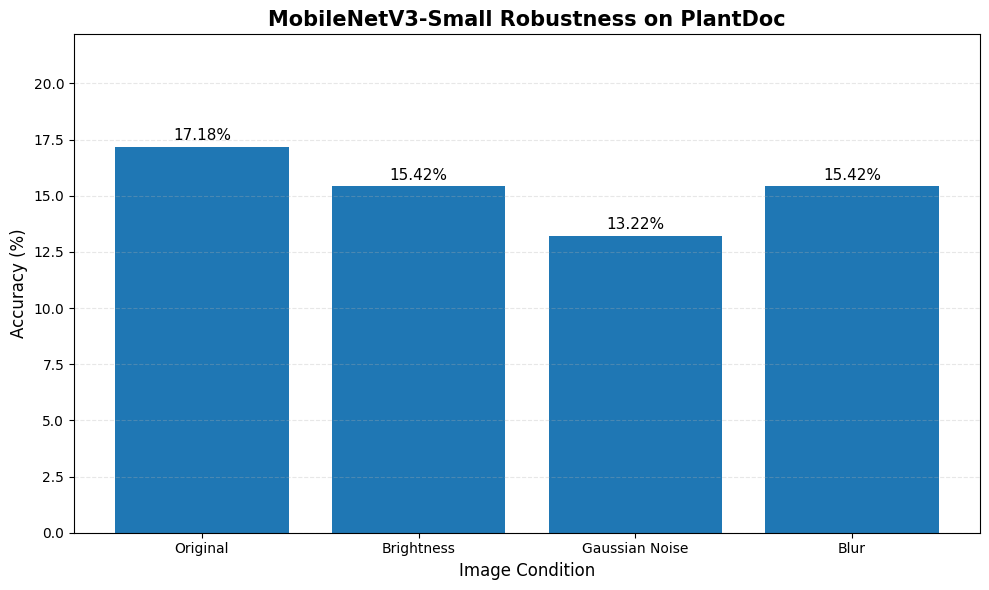


Robustness graph saved:
/kaggle/working/plant_disease_results/robustness/robustness_comparison.png

Interpretation saved:
/kaggle/working/plant_disease_results/robustness/robustness_interpretation.txt

ROBUSTNESS SUMMARY
Original            : 17.18%
Brightness          : 15.42%
Gaussian Noise      : 13.22%
Blur                : 15.42%

STEP 10 COMPLETED


In [11]:
# ============================================================
# STEP 10: ROBUSTNESS GRAPH + FINAL RESULT UPDATE
# ============================================================

import os
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 70)
print("STEP 10: ROBUSTNESS VISUALIZATION")
print("=" * 70)


# ============================================================
# LOAD ROBUSTNESS RESULTS
# ============================================================

robustness_csv = os.path.join(
    RESULTS_DIR,
    "robustness",
    "robustness_results.csv"
)

robustness_df = pd.read_csv(
    robustness_csv
)


print("\nRobustness results:")
print(
    robustness_df.to_string(
        index=False
    )
)


# ============================================================
# CREATE ROBUSTNESS GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    robustness_df["Condition"],
    robustness_df["Accuracy"]
)

plt.title(
    "MobileNetV3-Small Robustness on PlantDoc",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Image Condition",
    fontsize=12
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=12
)

plt.ylim(
    0,
    max(
        robustness_df["Accuracy"]
    ) + 5
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for i, value in enumerate(
    robustness_df["Accuracy"]
):

    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()


# ============================================================
# SAVE GRAPH
# ============================================================

robustness_graph_path = os.path.join(
    RESULTS_DIR,
    "robustness",
    "robustness_comparison.png"
)

plt.savefig(
    robustness_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


print(
    "\nRobustness graph saved:"
)

print(
    robustness_graph_path
)


# ============================================================
# CALCULATE DEGRADATION
# ============================================================

original_accuracy = robustness_df.loc[
    robustness_df["Condition"] == "Original",
    "Accuracy"
].iloc[0]


robustness_df[
    "Accuracy Drop"
] = (
    original_accuracy
    -
    robustness_df["Accuracy"]
)


# ============================================================
# SAVE UPDATED TABLE
# ============================================================

updated_csv = os.path.join(
    RESULTS_DIR,
    "robustness",
    "robustness_results_with_drop.csv"
)

robustness_df.to_csv(
    updated_csv,
    index=False
)


# ============================================================
# WRITE THESIS INTERPRETATION
# ============================================================

interpretation_path = os.path.join(
    RESULTS_DIR,
    "robustness",
    "robustness_interpretation.txt"
)


with open(
    interpretation_path,
    "w"
) as f:

    f.write(
        "ROBUSTNESS EVALUATION INTERPRETATION\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )

    f.write(
        "The trained MobileNetV3-Small model was evaluated "
        "on the unseen PlantDoc dataset under several "
        "controlled image perturbations.\n\n"
    )

    f.write(
        f"Original PlantDoc Accuracy: "
        f"{original_accuracy:.2f}%\n\n"
    )

    for _, row in robustness_df.iterrows():

        if row["Condition"] == "Original":
            continue

        f.write(
            f"{row['Condition']}: "
            f"{row['Accuracy']:.2f}% "
            f"(drop of "
            f"{row['Accuracy Drop']:.2f} percentage points)\n"
        )

    f.write(
        "\n"
    )

    max_drop_row = robustness_df.loc[
        robustness_df["Accuracy Drop"].idxmax()
    ]

    f.write(
        f"The largest performance degradation was observed "
        f"under {max_drop_row['Condition']}, with an accuracy "
        f"drop of {max_drop_row['Accuracy Drop']:.2f} "
        f"percentage points compared with the original "
        f"PlantDoc images.\n"
    )


print(
    "\nInterpretation saved:"
)

print(
    interpretation_path
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("ROBUSTNESS SUMMARY")
print("=" * 70)

for _, row in robustness_df.iterrows():

    print(
        f"{row['Condition']:20s}: "
        f"{row['Accuracy']:.2f}%"
    )


print("\n" + "=" * 70)
print("STEP 10 COMPLETED")
print("=" * 70)

STEP 11: COLORED GRAD-CAM

Device: cpu
Model: /kaggle/working/plant_disease_results/best_mobilenetv3_plantvillage.pth

✓ Model loaded successfully

PlantDoc images found: 236
Images selected: 6

Processing image 1:
Corn leaf blight (4).jpg


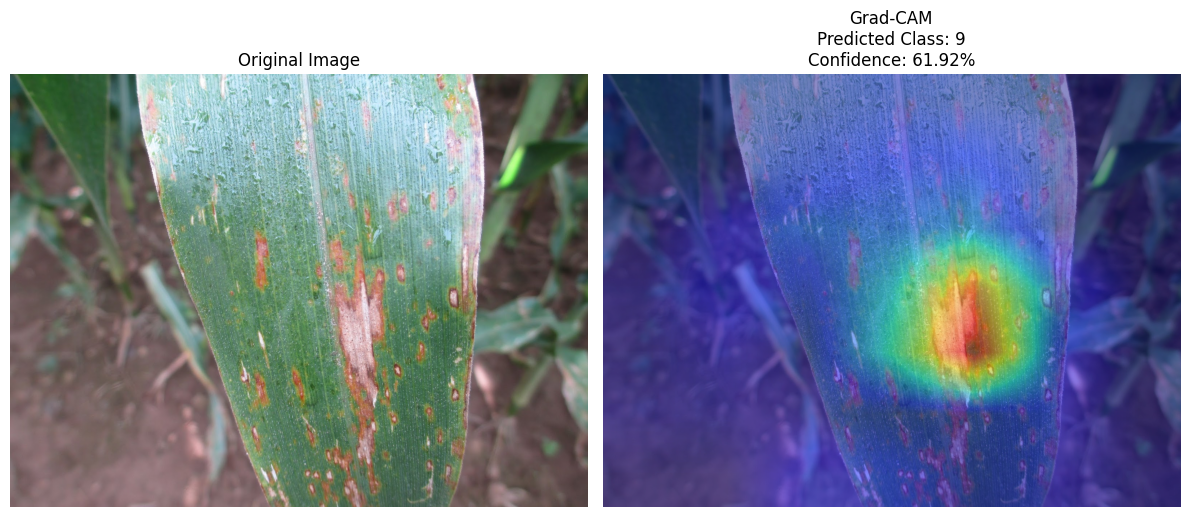

Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_1.png

Processing image 2:
Corn leaf blight (5).jpg


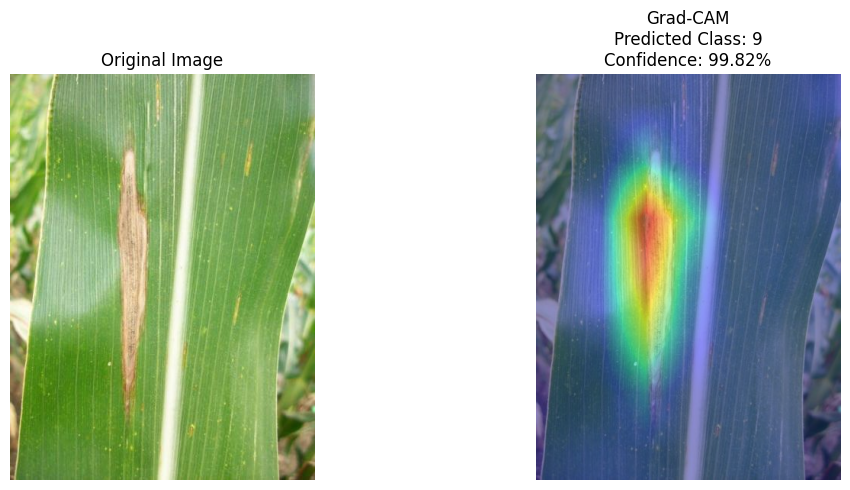

Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_2.png

Processing image 3:
Corn leaf blight (8).jpg


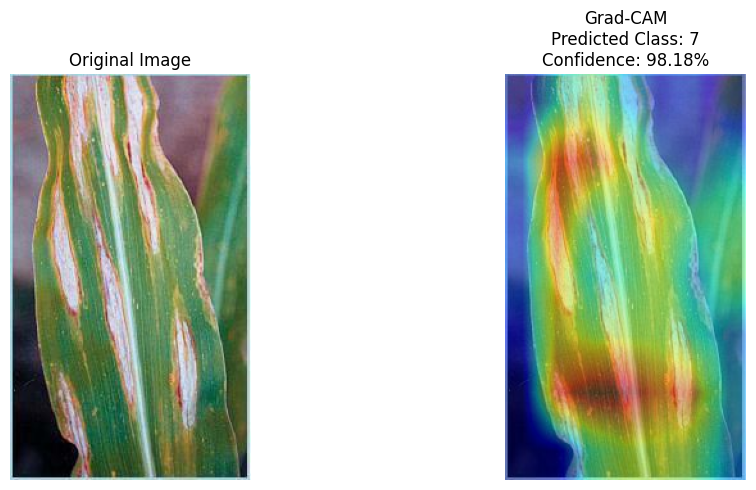

Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_3.png

Processing image 4:
Corn leaf blight (3).jpg


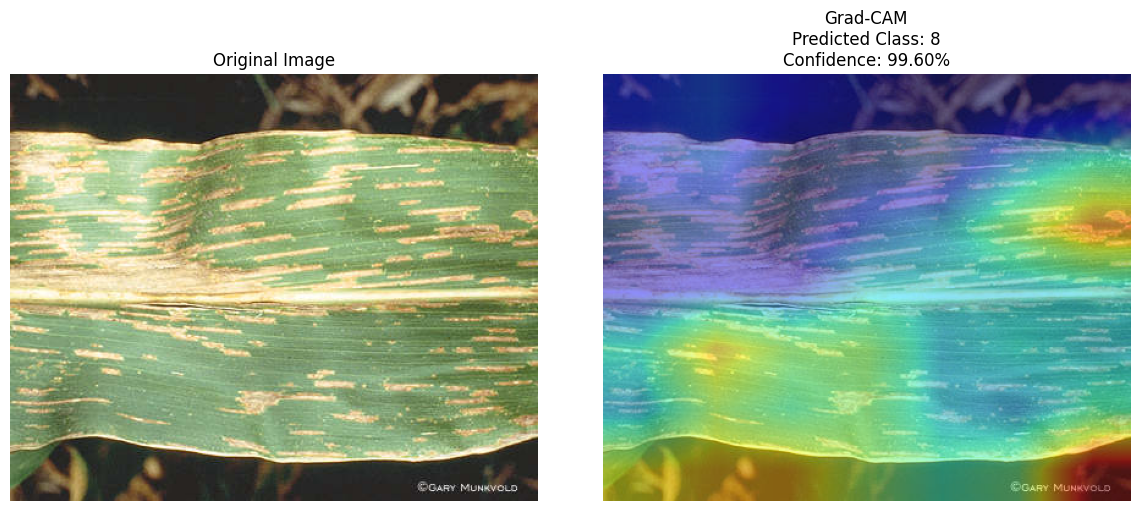

Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_4.png

Processing image 5:
Corn leaf blight (10).jpg


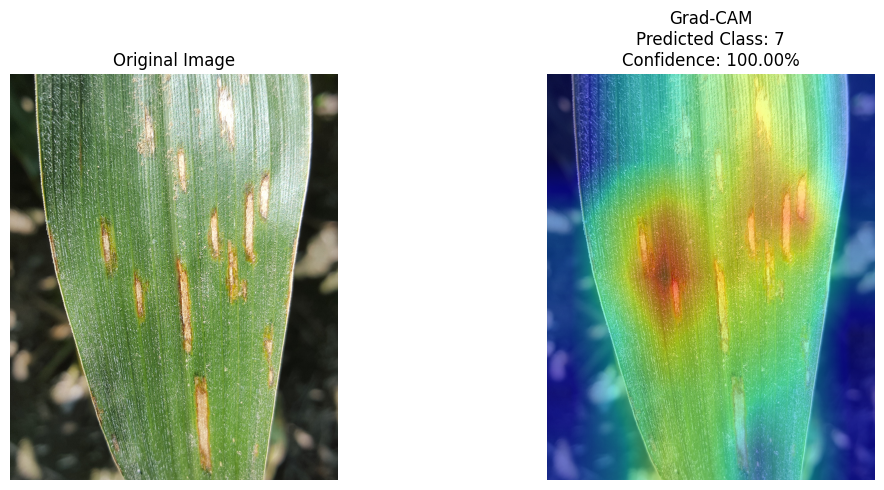

Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_5.png

Processing image 6:
Corn leaf blight (1).jpg


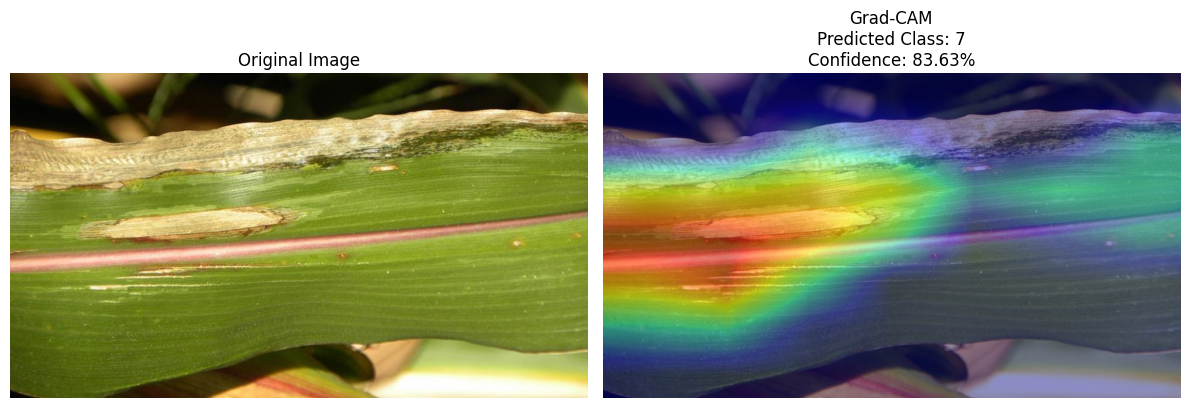

Saved: /kaggle/working/plant_disease_results/gradcam/gradcam_6.png

STEP 11 COMPLETED

Grad-CAM directory:
/kaggle/working/plant_disease_results/gradcam


In [12]:
# ============================================================
# STEP 11: COLORED GRAD-CAM EXPLAINABILITY
# ============================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms


print("=" * 70)
print("STEP 11: COLORED GRAD-CAM")
print("=" * 70)


# ============================================================
# SETTINGS
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MODEL_PATH = os.path.join(
    RESULTS_DIR,
    "best_mobilenetv3_plantvillage.pth"
)

GRADCAM_DIR = os.path.join(
    RESULTS_DIR,
    "gradcam"
)

os.makedirs(
    GRADCAM_DIR,
    exist_ok=True
)


print("\nDevice:", device)
print("Model:", MODEL_PATH)


# ============================================================
# LOAD MODEL
# ============================================================

model = models.mobilenet_v3_small(
    weights=None
)

model.classifier[3] = torch.nn.Linear(
    model.classifier[3].in_features,
    38
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)


if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    model.load_state_dict(
        checkpoint
    )


model = model.to(device)
model.eval()


print("\n✓ Model loaded successfully")


# ============================================================
# TRANSFORM
# ============================================================

transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


# ============================================================
# TARGET LAYER
# ============================================================

target_layer = model.features[-1]


# ============================================================
# GRAD-CAM FUNCTION
# ============================================================

def generate_gradcam(
    model,
    image_tensor,
    target_class
):

    activations = []
    gradients = []


    def forward_hook(
        module,
        input,
        output
    ):

        activations.append(
            output.detach()
        )


    def backward_hook(
        module,
        grad_input,
        grad_output
    ):

        gradients.append(
            grad_output[0].detach()
        )


    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )


    model.zero_grad()


    output = model(
        image_tensor
    )


    score = output[
        0,
        target_class
    ]


    score.backward()


    activation = activations[0]
    gradient = gradients[0]


    # --------------------------------------------------------
    # Global average pooling of gradients
    # --------------------------------------------------------

    weights = gradient.mean(
        dim=(2, 3),
        keepdim=True
    )


    # --------------------------------------------------------
    # Weighted activation
    # --------------------------------------------------------

    cam = (
        weights * activation
    ).sum(
        dim=1
    )


    cam = torch.relu(
        cam
    )


    cam = cam.squeeze().cpu().numpy()


    # --------------------------------------------------------
    # Normalize CAM
    # --------------------------------------------------------

    cam -= cam.min()

    if cam.max() > 0:

        cam /= cam.max()


    forward_handle.remove()
    backward_handle.remove()


    return cam


# ============================================================
# FIND PLANTDOC IMAGES
# ============================================================

plantdoc_root = (
    "/kaggle/input/datasets/"
    "abdulhasibuddin/"
    "plant-doc-dataset/"
    "PlantDoc-Dataset/"
    "test"
)


image_paths = []


for root, dirs, files in os.walk(
    plantdoc_root
):

    for file in files:

        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            image_paths.append(
                os.path.join(
                    root,
                    file
                )
            )


print(
    "\nPlantDoc images found:",
    len(image_paths)
)


# ============================================================
# SELECT REPRESENTATIVE IMAGES
# ============================================================

selected_images = image_paths[:6]


print(
    "Images selected:",
    len(selected_images)
)


# ============================================================
# GENERATE GRAD-CAM
# ============================================================

for image_number, image_path in enumerate(
    selected_images,
    start=1
):

    print(
        f"\nProcessing image {image_number}:"
    )

    print(
        os.path.basename(
            image_path
        )
    )


    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    original_image = Image.open(
        image_path
    ).convert(
        "RGB"
    )


    # --------------------------------------------------------
    # Prepare tensor
    # --------------------------------------------------------

    image_tensor = transform(
        original_image
    ).unsqueeze(
        0
    ).to(device)


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    with torch.no_grad():

        output = model(
            image_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = output.argmax(
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_class
        ].item() * 100


    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    cam = generate_gradcam(
        model,
        image_tensor,
        predicted_class
    )


    # --------------------------------------------------------
    # Resize CAM
    # --------------------------------------------------------

    cam_image = Image.fromarray(
        np.uint8(
            cam * 255
        )
    )

    cam_image = cam_image.resize(
        original_image.size,
        Image.Resampling.BILINEAR
    )


    cam_array = np.array(
        cam_image
    ) / 255.0


    # --------------------------------------------------------
    # CREATE FIGURE
    # --------------------------------------------------------

    plt.figure(
        figsize=(12, 5)
    )


    # Original
    plt.subplot(
        1,
        2,
        1
    )

    plt.imshow(
        original_image
    )

    plt.title(
        "Original Image"
    )

    plt.axis(
        "off"
    )


    # Grad-CAM
    plt.subplot(
        1,
        2,
        2
    )

    plt.imshow(
        original_image
    )

    plt.imshow(
        cam_array,
        cmap="jet",
        alpha=0.45
    )

    plt.title(
        f"Grad-CAM\n"
        f"Predicted Class: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis(
        "off"
    )


    plt.tight_layout()


    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    output_path = os.path.join(
        GRADCAM_DIR,
        f"gradcam_{image_number}.png"
    )


    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


    print(
        "Saved:",
        output_path
    )


print("\n" + "=" * 70)
print("STEP 11 COMPLETED")
print("=" * 70)

print(
    "\nGrad-CAM directory:"
)

print(
    GRADCAM_DIR
)

In [13]:
# ============================================================
# STEP 12: FINAL RESULT VERIFICATION + ZIP
# ============================================================

import os
import shutil

print("=" * 70)
print("STEP 12: FINAL RESULT VERIFICATION")
print("=" * 70)

FINAL_DIR = "/kaggle/working/plant_disease_FINAL"

os.makedirs(
    FINAL_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Important files
# ------------------------------------------------------------

important_files = [

    "best_mobilenetv3_plantvillage.pth",

    "training_history.pth",

    "final_results_summary.csv",

    "final_experiment_summary.txt",

    "plantdoc_cross_dataset_report.txt",

    "plantdoc_confusion_matrix.csv",

    "plantdoc_colored_confusion_matrix.png",

    "training_validation_accuracy.png",

    "training_validation_loss.png",
]

print("\nChecking important files...\n")

for filename in important_files:

    source = os.path.join(
        RESULTS_DIR,
        filename
    )

    if os.path.exists(source):

        shutil.copy2(
            source,
            os.path.join(
                FINAL_DIR,
                filename
            )
        )

        print("✓", filename)

    else:

        print("⚠ MISSING:", filename)


# ------------------------------------------------------------
# Copy robustness
# ------------------------------------------------------------

robustness_source = os.path.join(
    RESULTS_DIR,
    "robustness"
)

robustness_destination = os.path.join(
    FINAL_DIR,
    "robustness"
)

if os.path.exists(
    robustness_source
):

    shutil.copytree(
        robustness_source,
        robustness_destination,
        dirs_exist_ok=True
    )

    print(
        "✓ robustness/"
    )


# ------------------------------------------------------------
# Copy Grad-CAM
# ------------------------------------------------------------

gradcam_source = os.path.join(
    RESULTS_DIR,
    "gradcam"
)

gradcam_destination = os.path.join(
    FINAL_DIR,
    "gradcam"
)

if os.path.exists(
    gradcam_source
):

    shutil.copytree(
        gradcam_source,
        gradcam_destination,
        dirs_exist_ok=True
    )

    print(
        "✓ gradcam/"
    )


# ------------------------------------------------------------
# Create ZIP
# ------------------------------------------------------------

zip_path = shutil.make_archive(
    "/kaggle/working/plant_disease_FINAL",
    "zip",
    FINAL_DIR
)

print("\n" + "=" * 70)
print("FINAL PACKAGE CREATED")
print("=" * 70)

print(
    "\nFolder:"
)

print(
    FINAL_DIR
)

print(
    "\nZIP:"
)

print(
    zip_path
)

print("\n" + "=" * 70)
print("STEP 12 COMPLETED")
print("=" * 70)

STEP 12: FINAL RESULT VERIFICATION

Checking important files...

✓ best_mobilenetv3_plantvillage.pth
✓ training_history.pth
✓ final_results_summary.csv
✓ final_experiment_summary.txt
✓ plantdoc_cross_dataset_report.txt
✓ plantdoc_confusion_matrix.csv
✓ plantdoc_colored_confusion_matrix.png
✓ training_validation_accuracy.png
✓ training_validation_loss.png
✓ robustness/
✓ gradcam/

FINAL PACKAGE CREATED

Folder:
/kaggle/working/plant_disease_FINAL

ZIP:
/kaggle/working/plant_disease_FINAL.zip

STEP 12 COMPLETED


In [14]:
import os

print(os.path.exists("/kaggle/working/plant_disease_FINAL.zip"))
print(os.path.getsize("/kaggle/working/plant_disease_FINAL.zip") / (1024 * 1024), "MB")

True
23.57922077178955 MB


In [15]:
# ============================================================
# STEP 13: CROSS-DATASET VERIFICATION
# ============================================================

import torch
import torchvision
import numpy as np
import os

print("=" * 70)
print("STEP 13: CROSS-DATASET VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

print("\nLoading best trained model...")

checkpoint_path = (
    "/kaggle/working/plant_disease_results/"
    "best_mobilenetv3_plantvillage.pth"
)

print("Checkpoint:")
print(checkpoint_path)

print(
    "Exists:",
    os.path.exists(checkpoint_path)
)

# ------------------------------------------------------------
# Model architecture
# ------------------------------------------------------------

model = torchvision.models.mobilenet_v3_small(
    weights=None
)

model.classifier[3] = torch.nn.Linear(
    model.classifier[3].in_features,
    38
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

# ------------------------------------------------------------
# Handle checkpoint format
# ------------------------------------------------------------

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:

        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:

        state_dict = checkpoint["state_dict"]

    else:

        state_dict = checkpoint

else:

    state_dict = checkpoint


model.load_state_dict(
    state_dict
)

model = model.to(device)
model.eval()

print("\nModel loaded successfully.")

print(
    "Output classes:",
    model.classifier[3].out_features
)

print(
    "Model device:",
    next(model.parameters()).device
)

# ------------------------------------------------------------
# Verify PlantDoc loader
# ------------------------------------------------------------

print("\nPlantDoc loader:")

print(
    "Total images:",
    len(test_loader.dataset)
)

print(
    "Number of classes:",
    len(test_loader.dataset.classes)
)

print(
    "\nPlantDoc classes:"
)

for i, name in enumerate(
    test_loader.dataset.classes
):

    print(
        f"{i:2d} -> {name}"
    )

# ------------------------------------------------------------
# Verify class mapping
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFYING CLASS MAPPING")
print("=" * 70)

print(
    "\nPlantVillage classes:",
    len(plantvillage_classes)
)

print(
    "PlantDoc classes:",
    len(test_loader.dataset.classes)
)

print(
    "Valid mappings:",
    len(valid_mappings)
)

print("\nMappings:")

for pd_idx, pv_idx in valid_mappings.items():

    print(
        f"PlantDoc {pd_idx:2d} "
        f"-> PV {pv_idx:2d} "
        f"| {test_loader.dataset.classes[pd_idx]} "
        f"-> {plantvillage_classes[pv_idx]}"
    )

# ------------------------------------------------------------
# Preprocessing check
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PREPROCESSING CHECK")
print("=" * 70)

print(
    "\nImage size expected: 224 x 224"
)

print(
    "Batch shape:"
)

images, labels = next(
    iter(test_loader)
)

print(
    images.shape
)

print(
    "\nImage value range:"
)

print(
    "Min:",
    images.min().item()
)

print(
    "Max:",
    images.max().item()
)

print(
    "Mean:",
    images.mean().item()
)

print(
    "Std:",
    images.std().item()
)

# ------------------------------------------------------------
# Prediction verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PREDICTION CHECK")
print("=" * 70)

correct = 0
evaluated = 0
skipped = 0

sample_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        ).cpu().numpy()

        labels = labels.numpy()

        for true_pd, pred_pv in zip(
            labels,
            predictions
        ):

            if true_pd not in valid_mappings:

                skipped += 1
                continue

            expected_pv = valid_mappings[
                true_pd
            ]

            evaluated += 1

            if pred_pv == expected_pv:

                correct += 1

            if len(sample_predictions) < 20:

                sample_predictions.append(
                    (
                        int(true_pd),
                        int(expected_pv),
                        int(pred_pv)
                    )
                )

accuracy = (
    100.0 * correct / evaluated
    if evaluated > 0
    else 0.0
)

# ------------------------------------------------------------
# Final verification result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFICATION RESULT")
print("=" * 70)

print(
    f"\nEvaluated images : {evaluated}"
)

print(
    f"Skipped images   : {skipped}"
)

print(
    f"Correct          : {correct}"
)

print(
    f"Incorrect        : {evaluated - correct}"
)

print(
    f"Accuracy         : {accuracy:.2f}%"
)

print("\nSample predictions:")

for true_pd, expected_pv, pred_pv in sample_predictions:

    print(
        f"True PD={true_pd:2d} "
        f"Expected PV={expected_pv:2d} "
        f"Predicted PV={pred_pv:2d}"
    )

print("\n" + "=" * 70)
print("STEP 13 COMPLETED")
print("=" * 70)

STEP 13: CROSS-DATASET VERIFICATION

Device: cpu

Loading best trained model...
Checkpoint:
/kaggle/working/plant_disease_results/best_mobilenetv3_plantvillage.pth
Exists: True

Model loaded successfully.
Output classes: 38
Model device: cpu

PlantDoc loader:


NameError: name 'test_loader' is not defined

In [16]:
# ============================================================
# STEP 13A: RECREATE PLANTDOC TEST LOADER
# ============================================================

import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("=" * 70)
print("STEP 13A: RECREATING PLANTDOC TEST LOADER")
print("=" * 70)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PLANTDOC_TEST_DIR = (
    "/kaggle/input/datasets/"
    "abdulhasibuddin/"
    "plant-doc-dataset/"
    "PlantDoc-Dataset/"
    "test"
)

print("\nTest directory:")
print(PLANTDOC_TEST_DIR)

print(
    "\nDirectory exists:",
    os.path.exists(PLANTDOC_TEST_DIR)
)

# ------------------------------------------------------------
# Transform
# IMPORTANT:
# Same normalization used for MobileNetV3 training
# ------------------------------------------------------------

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

test_dataset = datasets.ImageFolder(
    PLANTDOC_TEST_DIR,
    transform=test_transform
)

# ------------------------------------------------------------
# DataLoader
# ------------------------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

# ------------------------------------------------------------
# Information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PLANTDOC DATASET INFORMATION")
print("=" * 70)

print(
    "\nTotal images:",
    len(test_dataset)
)

print(
    "Number of classes:",
    len(test_dataset.classes)
)

print(
    "Number of batches:",
    len(test_loader)
)

print("\nClasses:")

for i, name in enumerate(test_dataset.classes):

    print(
        f"{i:2d} -> {name}"
    )

# ------------------------------------------------------------
# Batch check
# ------------------------------------------------------------

images, labels = next(iter(test_loader))

print("\n" + "=" * 70)
print("LOADER CHECK")
print("=" * 70)

print(
    "\nImage batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

print(
    "First labels:",
    labels[:10].tolist()
)

print("\n" + "=" * 70)
print("STEP 13A COMPLETED")
print("=" * 70)

STEP 13A: RECREATING PLANTDOC TEST LOADER

Test directory:
/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test

Directory exists: True

PLANTDOC DATASET INFORMATION

Total images: 236
Number of classes: 27
Number of batches: 8

Classes:
 0 -> Apple Scab Leaf
 1 -> Apple leaf
 2 -> Apple rust leaf
 3 -> Bell_pepper leaf
 4 -> Bell_pepper leaf spot
 5 -> Blueberry leaf
 6 -> Cherry leaf
 7 -> Corn Gray leaf spot
 8 -> Corn leaf blight
 9 -> Corn rust leaf
10 -> Peach leaf
11 -> Potato leaf early blight
12 -> Potato leaf late blight
13 -> Raspberry leaf
14 -> Soyabean leaf
15 -> Squash Powdery mildew leaf
16 -> Strawberry leaf
17 -> Tomato Early blight leaf
18 -> Tomato Septoria leaf spot
19 -> Tomato leaf
20 -> Tomato leaf bacterial spot
21 -> Tomato leaf late blight
22 -> Tomato leaf mosaic virus
23 -> Tomato leaf yellow virus
24 -> Tomato mold leaf
25 -> grape leaf
26 -> grape leaf black rot

LOADER CHECK

Image batch shape: torch.Size([32, 3, 224, 224])
Labe

In [17]:
# ============================================================
# STEP 13B: VERIFY EXISTING MODEL ON PLANTDOC
# ============================================================

import torch
import numpy as np

print("=" * 70)
print("STEP 13B: EXISTING MODEL VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Make sure model is in evaluation mode
# ------------------------------------------------------------

model.eval()

print("\nModel ready:")
print(type(model))
print("Device:", next(model.parameters()).device)

# ------------------------------------------------------------
# PlantVillage class list
# ------------------------------------------------------------

plantvillage_classes = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",
    "Blueberry___healthy",
    "Cherry_(including_sour)___Powdery_mildew",
    "Cherry_(including_sour)___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",
    "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Grape___healthy",
    "Orange___Haunglongbing_(Citrus_greening)",
    "Peach___Bacterial_spot",
    "Peach___healthy",
    "Pepper,_bell___Bacterial_spot",
    "Pepper,_bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Raspberry___healthy",
    "Soybean___healthy",
    "Squash___Powdery_mildew",
    "Strawberry___Leaf_scorch",
    "Strawberry___healthy",
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy"
]

# ------------------------------------------------------------
# PlantDoc -> PlantVillage mapping
# ------------------------------------------------------------

mapping_by_name = {

    "Apple Scab Leaf":
        "Apple___Apple_scab",

    "Apple rust leaf":
        "Apple___Cedar_apple_rust",

    "Bell_pepper leaf":
        "Pepper,_bell___healthy",

    "Bell_pepper leaf spot":
        "Pepper,_bell___Bacterial_spot",

    "Blueberry leaf":
        "Blueberry___healthy",

    "Cherry leaf":
        "Cherry_(including_sour)___healthy",

    "Corn Gray leaf spot":
        "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",

    "Corn leaf blight":
        "Corn_(maize)___Northern_Leaf_Blight",

    "Corn rust leaf":
        "Corn_(maize)___Common_rust_",

    "Peach leaf":
        "Peach___healthy",

    "Potato leaf early blight":
        "Potato___Early_blight",

    "Potato leaf late blight":
        "Potato___Late_blight",

    "Raspberry leaf":
        "Raspberry___healthy",

    "Soyabean leaf":
        "Soybean___healthy",

    "Squash Powdery mildew leaf":
        "Squash___Powdery_mildew",

    "Strawberry leaf":
        "Strawberry___healthy",

    "Tomato Early blight leaf":
        "Tomato___Early_blight",

    "Tomato Septoria leaf spot":
        "Tomato___Septoria_leaf_spot",

    "Tomato leaf":
        "Tomato___healthy",

    "Tomato leaf bacterial spot":
        "Tomato___Bacterial_spot",

    "Tomato leaf late blight":
        "Tomato___Late_blight",

    "Tomato leaf mosaic virus":
        "Tomato___Tomato_mosaic_virus",

    "Tomato leaf yellow virus":
        "Tomato___Tomato_Yellow_Leaf_Curl_Virus",

    "Tomato mold leaf":
        "Tomato___Leaf_Mold",

    "grape leaf":
        "Grape___healthy",

    "grape leaf black rot":
        "Grape___Black_rot"
}

# ------------------------------------------------------------
# Convert mapping to index mapping
# ------------------------------------------------------------

valid_mappings = {}

for pd_idx, pd_name in enumerate(test_dataset.classes):

    if pd_name in mapping_by_name:

        pv_name = mapping_by_name[pd_name]

        if pv_name in plantvillage_classes:

            pv_idx = plantvillage_classes.index(
                pv_name
            )

            valid_mappings[pd_idx] = pv_idx

print("\n" + "=" * 70)
print("MAPPING VERIFICATION")
print("=" * 70)

print(
    "\nPlantDoc classes:",
    len(test_dataset.classes)
)

print(
    "Mapped classes:",
    len(valid_mappings)
)

print(
    "Unmapped classes:",
    len(test_dataset.classes) -
    len(valid_mappings)
)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

y_true = []
y_pred = []

correct = 0
evaluated = 0
skipped = 0

print("\nRunning evaluation...")

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        ).cpu().numpy()

        labels = labels.numpy()

        for true_pd, pred_pv in zip(
            labels,
            predictions
        ):

            true_pd = int(true_pd)
            pred_pv = int(pred_pv)

            # Skip unmapped PlantDoc class
            if true_pd not in valid_mappings:

                skipped += 1
                continue

            expected_pv = valid_mappings[true_pd]

            y_true.append(expected_pv)
            y_pred.append(pred_pv)

            evaluated += 1

            if pred_pv == expected_pv:

                correct += 1

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

accuracy = (
    100.0 * correct / evaluated
    if evaluated > 0
    else 0.0
)

# ------------------------------------------------------------
# Result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFICATION RESULT")
print("=" * 70)

print(
    f"\nTotal PlantDoc images : {len(test_dataset)}"
)

print(
    f"Evaluated             : {evaluated}"
)

print(
    f"Skipped               : {skipped}"
)

print(
    f"Correct               : {correct}"
)

print(
    f"Incorrect             : {evaluated - correct}"
)

print(
    f"Accuracy              : {accuracy:.2f}%"
)

# ------------------------------------------------------------
# Compare with previous result
# ------------------------------------------------------------

previous_accuracy = 17.18

print("\n" + "=" * 70)
print("COMPARISON")
print("=" * 70)

print(
    f"\nPrevious accuracy : {previous_accuracy:.2f}%"
)

print(
    f"Verified accuracy : {accuracy:.2f}%"
)

print(
    f"Difference        : "
    f"{accuracy - previous_accuracy:+.2f} percentage points"
)

if abs(accuracy - previous_accuracy) < 0.01:

    print(
        "\n✓ RESULT CONFIRMED"
    )

else:

    print(
        "\n⚠ RESULT DIFFERENCE DETECTED"
    )

print("\n" + "=" * 70)
print("STEP 13B COMPLETED")
print("=" * 70)

STEP 13B: EXISTING MODEL VERIFICATION

Model ready:
<class 'torchvision.models.mobilenetv3.MobileNetV3'>
Device: cpu

MAPPING VERIFICATION

PlantDoc classes: 27
Mapped classes: 26
Unmapped classes: 1

Running evaluation...

VERIFICATION RESULT

Total PlantDoc images : 236
Evaluated             : 227
Skipped               : 9
Correct               : 39
Incorrect             : 188
Accuracy              : 17.18%

COMPARISON

Previous accuracy : 17.18%
Verified accuracy : 17.18%
Difference        : +0.00 percentage points

✓ RESULT CONFIRMED

STEP 13B COMPLETED


In [18]:
# ============================================================
# STEP 14: TEST-TIME AUGMENTATION (TTA)
# ============================================================

import torch
from torchvision import transforms

print("=" * 70)
print("STEP 14: TEST-TIME AUGMENTATION")
print("=" * 70)

model.eval()

# ------------------------------------------------------------
# TTA transforms
# ------------------------------------------------------------

tta_transforms = {

    "Original": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]),

    "Horizontal Flip": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]),

    "Slight Brightness": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(
            brightness=0.10
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
}

# ------------------------------------------------------------
# Create TTA dataset loaders
# ------------------------------------------------------------

tta_loaders = {}

for name, transform in tta_transforms.items():

    dataset = datasets.ImageFolder(
        PLANTDOC_TEST_DIR,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2
    )

    tta_loaders[name] = loader

    print(
        f"\n{name}: {len(dataset)} images"
    )

# ------------------------------------------------------------
# Collect predictions
# ------------------------------------------------------------

all_probabilities = []

for name, loader in tta_loaders.items():

    print(
        f"\nEvaluating: {name}"
    )

    probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            probabilities.append(
                probs.cpu()
            )

    probabilities = torch.cat(
        probabilities,
        dim=0
    )

    all_probabilities.append(
        probabilities
    )

# ------------------------------------------------------------
# Average predictions
# ------------------------------------------------------------

ensemble_probabilities = torch.stack(
    all_probabilities,
    dim=0
).mean(dim=0)

ensemble_predictions = torch.argmax(
    ensemble_probabilities,
    dim=1
).numpy()

# ------------------------------------------------------------
# Get true labels
# ------------------------------------------------------------

true_labels = []

for _, labels in tta_loaders["Original"]:

    true_labels.extend(
        labels.numpy().tolist()
    )

# ------------------------------------------------------------
# Evaluate using PlantDoc -> PlantVillage mapping
# ------------------------------------------------------------

correct = 0
evaluated = 0
skipped = 0

for true_pd, pred_pv in zip(
    true_labels,
    ensemble_predictions
):

    true_pd = int(true_pd)
    pred_pv = int(pred_pv)

    if true_pd not in valid_mappings:

        skipped += 1
        continue

    expected_pv = valid_mappings[
        true_pd
    ]

    evaluated += 1

    if pred_pv == expected_pv:

        correct += 1

tta_accuracy = (
    100.0 * correct / evaluated
    if evaluated > 0
    else 0.0
)

# ------------------------------------------------------------
# Result
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TTA RESULTS")
print("=" * 70)

print(
    f"\nOriginal Accuracy : 17.18%"
)

print(
    f"TTA Accuracy      : {tta_accuracy:.2f}%"
)

print(
    f"Improvement       : "
    f"{tta_accuracy - 17.18:+.2f} percentage points"
)

print(
    f"\nEvaluated images  : {evaluated}"
)

print(
    f"Correct           : {correct}"
)

print(
    f"Incorrect         : {evaluated - correct}"
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

tta_dir = os.path.join(
    RESULTS_DIR,
    "tta"
)

os.makedirs(
    tta_dir,
    exist_ok=True
)

with open(
    os.path.join(
        tta_dir,
        "tta_results.txt"
    ),
    "w"
) as f:

    f.write(
        "PlantDoc Test-Time Augmentation Results\n"
    )

    f.write(
        f"Original Accuracy: 17.18%\n"
    )

    f.write(
        f"TTA Accuracy: {tta_accuracy:.2f}%\n"
    )

    f.write(
        f"Improvement: "
        f"{tta_accuracy - 17.18:+.2f} percentage points\n"
    )

print(
    "\nSaved:"
)

print(
    os.path.join(
        tta_dir,
        "tta_results.txt"
    )
)

print("\n" + "=" * 70)
print("STEP 14 COMPLETED")
print("=" * 70)

STEP 14: TEST-TIME AUGMENTATION

Original: 236 images

Horizontal Flip: 236 images

Slight Brightness: 236 images

Evaluating: Original

Evaluating: Horizontal Flip

Evaluating: Slight Brightness

TTA RESULTS

Original Accuracy : 17.18%
TTA Accuracy      : 16.74%
Improvement       : -0.44 percentage points

Evaluated images  : 227
Correct           : 38
Incorrect         : 189

Saved:
/kaggle/working/plant_disease_results/tta/tta_results.txt

STEP 14 COMPLETED
